<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">07. PR/FAR Rolling-Window Attribution</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Computes regional Probability Ratio (PR) and Fraction of Attributable Risk (FAR) time series using the Kharin & Zwiers (2005) rolling-window empirical method. For each 20-year window, 600 samples per forcing world (30 members x 20 years) are pooled and compared against a fixed reference threshold R0 to estimate exceedance probabilities. Historical windows span centred 1860 to 2004, limited by the MPI-GE historical/hist-nat record ending 2014.</p>
</div>

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']

rx5day_ant = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')
rx5day_nat = xr.open_dataset(OUTPUT_DIR + 'rx5day_nat_regional.nc')

# confirm region name -> index mapping matches REGION_ORDER
print(list(rx5day_nat.names.values))

# subset nat to the 1981-2010 baseline window
nat_baseline = rx5day_nat.sel(year=slice(1981, 2010))
print(nat_baseline.dims)  

[np.str_('Central_India'), np.str_('Indo_Gangetic_Plain'), np.str_('Northeast'), np.str_('Western_Ghats')]
FrozenMappingWarningOnValuesAccess({'year': 30, 'member': 30, 'region': 4})


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 1: Reference Threshold R0</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Defines R0 as the empirical 1-in-10 year regional Rx5day level (90th percentile), computed once from the natural-forcing 1981-2010 window (30 members x 30 years = 900 samples per region). This threshold is held fixed across all rolling windows in Part 2.</p>
</div>

In [12]:
nat_baseline = rx5day_nat.sel(year=slice(1981, 2010))

R0 = {}
for i, region in enumerate(REGION_ORDER):
    vals = nat_baseline['rx5day_nat_regional'].isel(region=i).values.flatten()
    R0[region] = np.nanpercentile(vals, 90)
    print(f"{region:<22} R0 = {R0[region]:.2f} mm  (n={len(vals)})")

Central_India          R0 = 131.27 mm  (n=900)
Indo_Gangetic_Plain    R0 = 110.54 mm  (n=900)
Northeast              R0 = 164.32 mm  (n=900)
Western_Ghats          R0 = 104.43 mm  (n=900)


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 2: Rolling-Window PR/FAR Engine</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Slides a 20-year window (t-10 to t+9, following Chris's worked example of a window centred on 1960 covering 1950-1969) one year at a time across the full 1850-2014 MPI-GE record. At each window position, 600 samples per forcing world (30 members x 20 years) are pooled per region, and compared against the fixed R0 threshold from Part 1 to yield Pant(t), Pnat(t), PR(t), and FAR(t).</p>
</div>

In [13]:
WINDOW_WIDTH = 20
HALF_BEFORE = 10  # t-10
HALF_AFTER = 9    # t+9

year_min = int(rx5day_ant.year.min())
year_max = int(rx5day_ant.year.max())

centre_years = [t for t in range(year_min, year_max + 1)
                if (t - HALF_BEFORE) >= year_min and (t + HALF_AFTER) <= year_max]

print(f"Data spans {year_min}-{year_max}")
print(f"Valid window centres: {centre_years[0]} to {centre_years[-1]} ({len(centre_years)} windows)")
print(f"First window: {centre_years[0]-HALF_BEFORE}-{centre_years[0]+HALF_AFTER}")
print(f"Last window:  {centre_years[-1]-HALF_BEFORE}-{centre_years[-1]+HALF_AFTER}")

Data spans 1850-2014
Valid window centres: 1860 to 2005 (146 windows)
First window: 1850-1869
Last window:  1995-2014


In [14]:
import pandas as pd

def pool_window(ds, varname, region_idx, centre_year):
    """Pool all member x year samples within the 20-year window centred on centre_year."""
    window = ds[varname].isel(region=region_idx).sel(
        year=slice(centre_year - HALF_BEFORE, centre_year + HALF_AFTER))
    return window.values.flatten()

results_pr = []

for region_idx, region in enumerate(REGION_ORDER):
    threshold = R0[region]
    for t in centre_years:
        ant_samples = pool_window(rx5day_ant, 'rx5day_ant_regional', region_idx, t)
        nat_samples = pool_window(rx5day_nat, 'rx5day_nat_regional', region_idx, t)

        n_ant, n_nat = len(ant_samples), len(nat_samples)
        assert n_ant == 600 and n_nat == 600, f"Unexpected sample size at t={t}: {n_ant}, {n_nat}"

        P_ant = np.mean(ant_samples > threshold)
        P_nat = np.mean(nat_samples > threshold)

        # Guard against P_nat = 0, which would make PR undefined (division by zero)
        PR = P_ant / P_nat if P_nat > 0 else np.nan
        FAR = 1 - (1 / PR) if (not np.isnan(PR) and PR > 0) else np.nan

        results_pr.append({
            'region': region, 'year': t,
            'P_ant': P_ant, 'P_nat': P_nat, 'PR': PR, 'FAR': FAR,
            'n_ant': n_ant, 'n_nat': n_nat
        })

pr_df = pd.DataFrame(results_pr)
print(f"Total rows: {len(pr_df)}  (expected {len(REGION_ORDER)} x {len(centre_years)} = {len(REGION_ORDER)*len(centre_years)})")
print(pr_df.groupby('region')[['PR', 'FAR']].describe())

Total rows: 584  (expected 4 x 146 = 584)
                        PR                                                    \
                     count      mean       std       min       25%       50%   
region                                                                         
Central_India        146.0  1.149982  0.162370  0.753846  1.039370  1.128074   
Indo_Gangetic_Plain  146.0  1.002077  0.144741  0.750000  0.898469  0.978019   
Northeast            146.0  1.238049  0.170746  0.905660  1.133898  1.214891   
Western_Ghats        146.0  1.051502  0.199134  0.746988  0.891142  1.027032   

                                           FAR                                \
                          75%       max  count      mean       std       min   
region                                                                         
Central_India        1.265017  1.622222  146.0  0.113121  0.125566 -0.326531   
Indo_Gangetic_Plain  1.065559  1.456140  146.0 -0.016848  0.134033 -0.333333 

In [15]:
print(pr_df['PR'].isna().sum(), "NaN PR values out of", len(pr_df))

0 NaN PR values out of 584


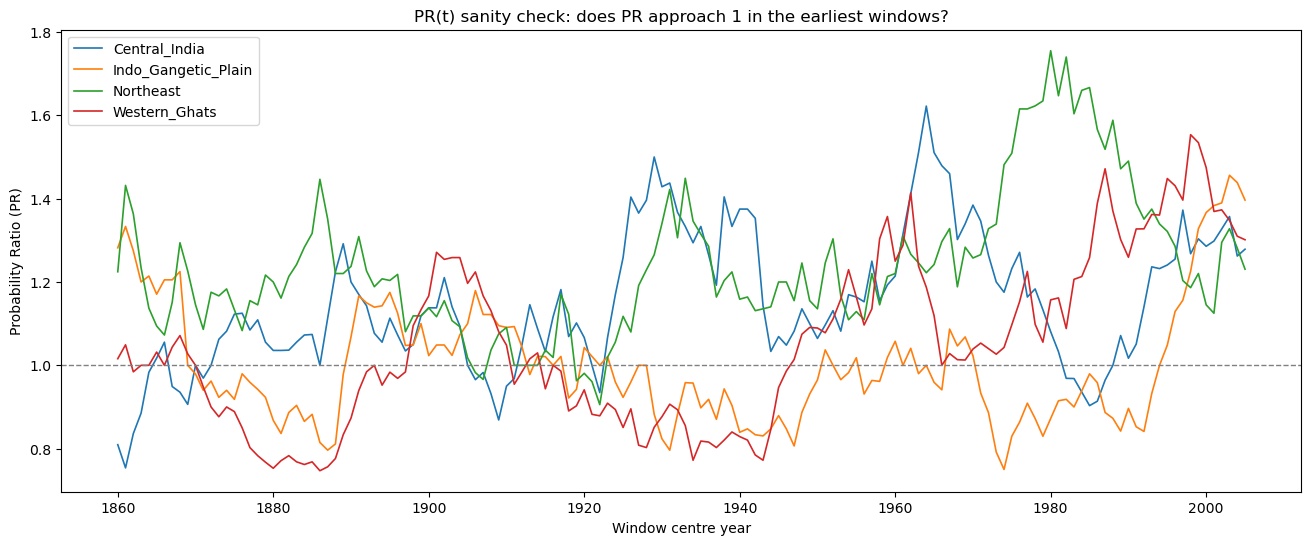

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
for region in REGION_ORDER:
    sub = pr_df[pr_df.region == region]
    ax.plot(sub['year'], sub['PR'], label=region, linewidth=1.2)
ax.axhline(1, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Window centre year')
ax.set_ylabel('Probability Ratio (PR)')
ax.legend()
ax.set_title('PR(t) sanity check: does PR approach 1 in the earliest windows?')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 3: Bootstrap Confidence Intervals for PR(t)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">For each window and region, resamples ensemble members with replacement (1000 iterations) to quantify sampling uncertainty in PR(t). Resampling is done at the member level (not the pooled 600-sample level), since the 20 years within one member are not independent draws. A window's signal is treated as detectable only where the 90% confidence interval excludes PR=1.</p>
</div>

In [17]:
N_BOOT = 1000
np.random.seed(42)

boot_records = []

for region_idx, region in enumerate(REGION_ORDER):
    threshold = R0[region]
    for t in centre_years:
        # shape: (30 members, 20 years)
        ant_window = rx5day_ant['rx5day_ant_regional'].isel(region=region_idx).sel(
            year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values
        nat_window = rx5day_nat['rx5day_nat_regional'].isel(region=region_idx).sel(
            year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values

        n_members = ant_window.shape[0]  # 30

        # resample member indices, shape (N_BOOT, n_members)
        idx = np.random.choice(n_members, size=(N_BOOT, n_members), replace=True)

        # gather resampled members -> shape (N_BOOT, n_members, 20 years), then flatten to (N_BOOT, 600)
        ant_boot = ant_window[idx].reshape(N_BOOT, -1)
        nat_boot = nat_window[idx].reshape(N_BOOT, -1)

        P_ant_boot = (ant_boot > threshold).mean(axis=1)
        P_nat_boot = (nat_boot > threshold).mean(axis=1)

        with np.errstate(divide='ignore', invalid='ignore'):
            PR_boot = np.where(P_nat_boot > 0, P_ant_boot / P_nat_boot, np.nan)

        lo, hi = np.nanpercentile(PR_boot, [5, 95])
        n_failed = int(np.sum(np.isnan(PR_boot)))

        boot_records.append({
            'region': region, 'year': t,
            'PR_boot_5': lo, 'PR_boot_95': hi,
            'n_boot_failed': n_failed,
            'significant': (lo > 1) or (hi < 1)
        })

boot_df = pd.DataFrame(boot_records)
pr_df = pr_df.merge(boot_df, on=['region', 'year'])

print(pr_df.groupby('region')['significant'].mean())
print(f"\nTotal windows with failed bootstrap draws: {(pr_df['n_boot_failed'] > 0).sum()} out of {len(pr_df)}")

region
Central_India          0.178082
Indo_Gangetic_Plain    0.047945
Northeast              0.267123
Western_Ghats          0.267123
Name: significant, dtype: float64

Total windows with failed bootstrap draws: 0 out of 584


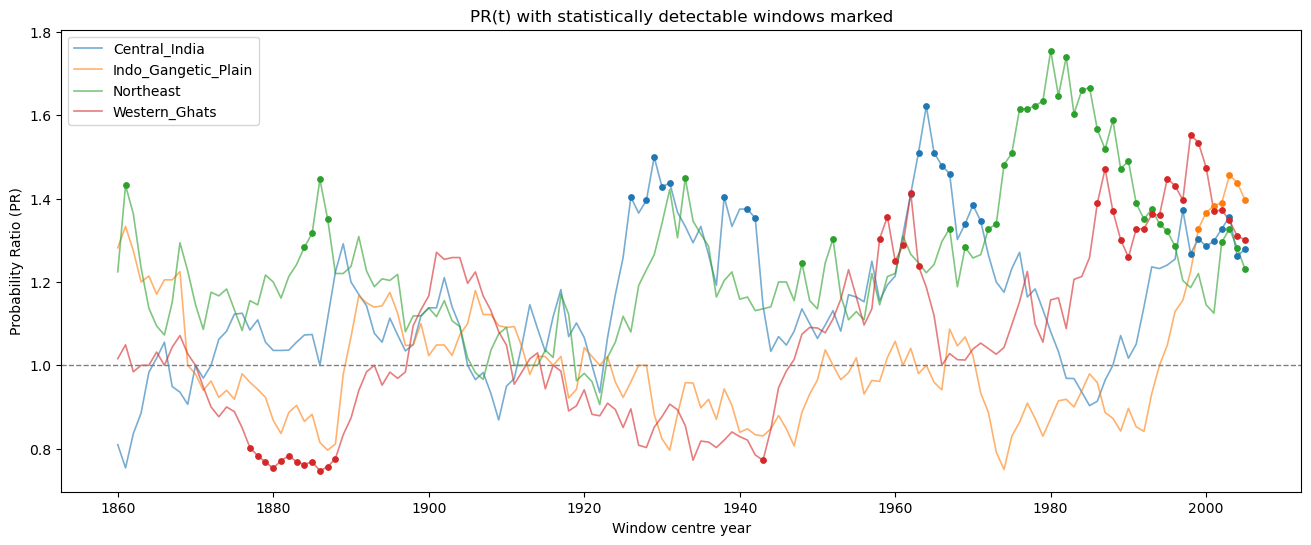

In [18]:
fig, ax = plt.subplots(figsize=(16, 6))
for region in REGION_ORDER:
    sub = pr_df[pr_df.region == region]
    sig = sub[sub['significant']]
    ax.plot(sub['year'], sub['PR'], linewidth=1.2, label=region, alpha=0.6)
    ax.scatter(sig['year'], sig['PR'], s=15, zorder=5)
ax.axhline(1, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Window centre year')
ax.set_ylabel('Probability Ratio (PR)')
ax.legend()
ax.set_title('PR(t) with statistically detectable windows marked')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 4: Representative Window Illustration</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Illustrates the rolling-window method for a single representative window (centred 2000, covering 1990-2009), showing the 600-sample distributions for both forcing worlds per region, with the fixed R0 threshold marked.</p>
</div>

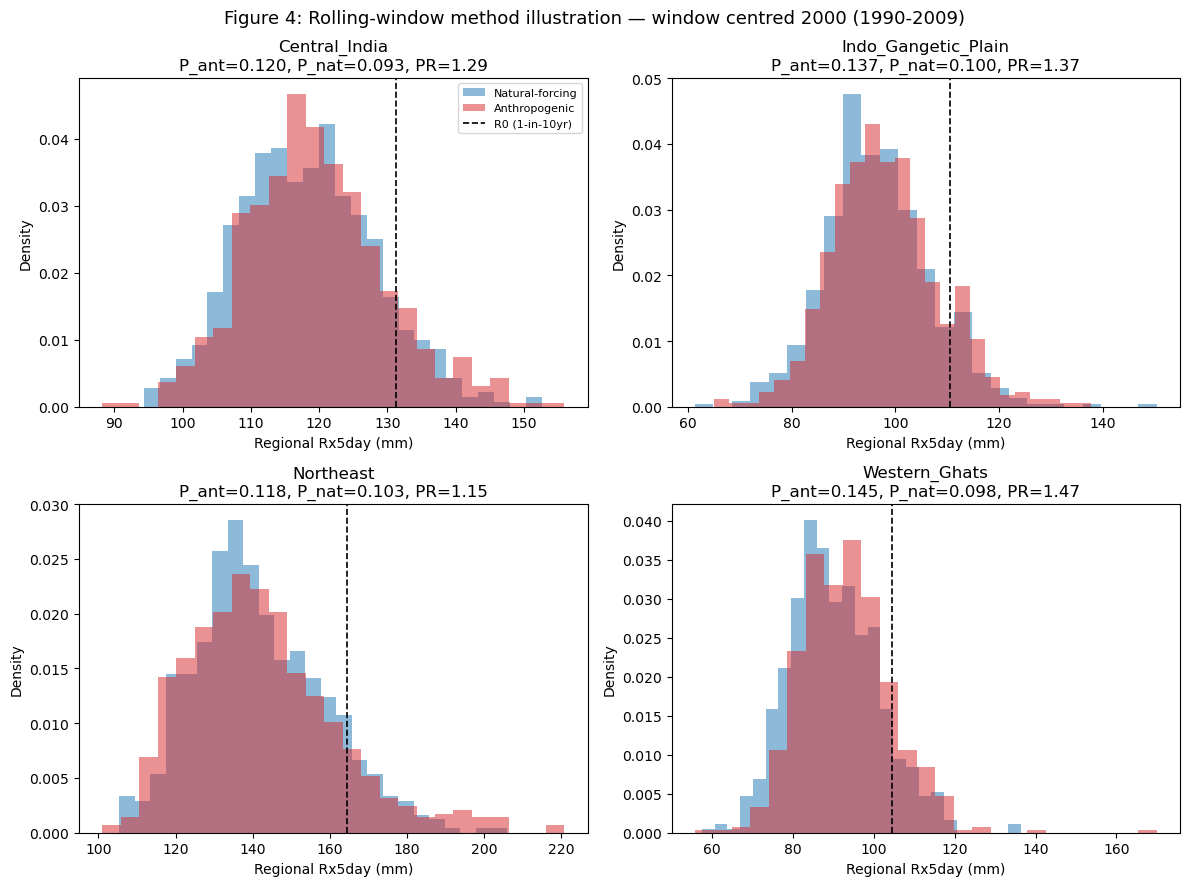

In [19]:
EXAMPLE_YEAR = 2000

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, region_idx_and_name in zip(axes.flat, enumerate(REGION_ORDER)):
    region_idx, region = region_idx_and_name
    threshold = R0[region]

    ant_window = rx5day_ant['rx5day_ant_regional'].isel(region=region_idx).sel(
        year=slice(EXAMPLE_YEAR - HALF_BEFORE, EXAMPLE_YEAR + HALF_AFTER)).values.flatten()
    nat_window = rx5day_nat['rx5day_nat_regional'].isel(region=region_idx).sel(
        year=slice(EXAMPLE_YEAR - HALF_BEFORE, EXAMPLE_YEAR + HALF_AFTER)).values.flatten()

    P_ant = np.mean(ant_window > threshold)
    P_nat = np.mean(nat_window > threshold)
    PR = P_ant / P_nat

    ax.hist(nat_window, bins=25, alpha=0.5, label='Natural-forcing', color='#1f77b4', density=True)
    ax.hist(ant_window, bins=25, alpha=0.5, label='Anthropogenic', color='#d62728', density=True)
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2, label='R0 (1-in-10yr)')

    ax.set_title(f'{region}\nP_ant={P_ant:.3f}, P_nat={P_nat:.3f}, PR={PR:.2f}')
    ax.set_xlabel('Regional Rx5day (mm)')
    ax.set_ylabel('Density')
    if region_idx == 0:
        ax.legend(fontsize=8)

fig.suptitle(f'Figure 4: Rolling-window method illustration — window centred {EXAMPLE_YEAR} (1990-2009)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure4_window_illustration.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 5: Save PR/FAR Results</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves the full PR(t)/FAR(t) time series per region, including bootstrap 90% confidence interval bounds and the significance flag, for use in the final figure and in Section 3.7 (damage amplification propagation).</p>
</div>

In [11]:
pr_df_out = pr_df[['region', 'year', 'P_ant', 'P_nat', 'PR', 'FAR',
                    'PR_boot_5', 'PR_boot_95', 'significant', 'n_boot_failed']]

pr_df_out.to_csv(OUTPUT_DIR + 'pr_far_rolling_window_results.csv', index=False)
print(f"Saved {len(pr_df_out)} rows")
print(pr_df_out.head())

Saved 584 rows
          region  year     P_ant     P_nat        PR       FAR  PR_boot_5  \
0  Central_India  1860  0.085000  0.105000  0.809524 -0.235294   0.594410   
1  Central_India  1861  0.081667  0.108333  0.753846 -0.326531   0.563537   
2  Central_India  1862  0.085000  0.101667  0.836066 -0.196078   0.597015   
3  Central_India  1863  0.090000  0.101667  0.885246 -0.129630   0.652715   
4  Central_India  1864  0.098333  0.100000  0.983333 -0.016949   0.731140   

   PR_boot_95  significant  n_boot_failed  
0    1.097263        False              0  
1    1.016142        False              0  
2    1.142857        False              0  
3    1.208494        False              0  
4    1.318182        False              0  


In [12]:
check = pd.read_csv(OUTPUT_DIR + 'pr_far_rolling_window_results.csv')
print(check.shape)
print(check.groupby('region').size())

(584, 10)
region
Central_India          146
Indo_Gangetic_Plain    146
Northeast              146
Western_Ghats          146
dtype: int64


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 6: Final PR(t) Time Series (Results Part 1 Headline Figure)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Regional Probability Ratio time series, 1860-2005 (window centre years), with 90% bootstrap confidence bands. This is the primary attribution result for Results Part 1, showing how the anthropogenic signal in extreme monsoon rainfall has evolved from the industrial period to the present.</p>
</div>

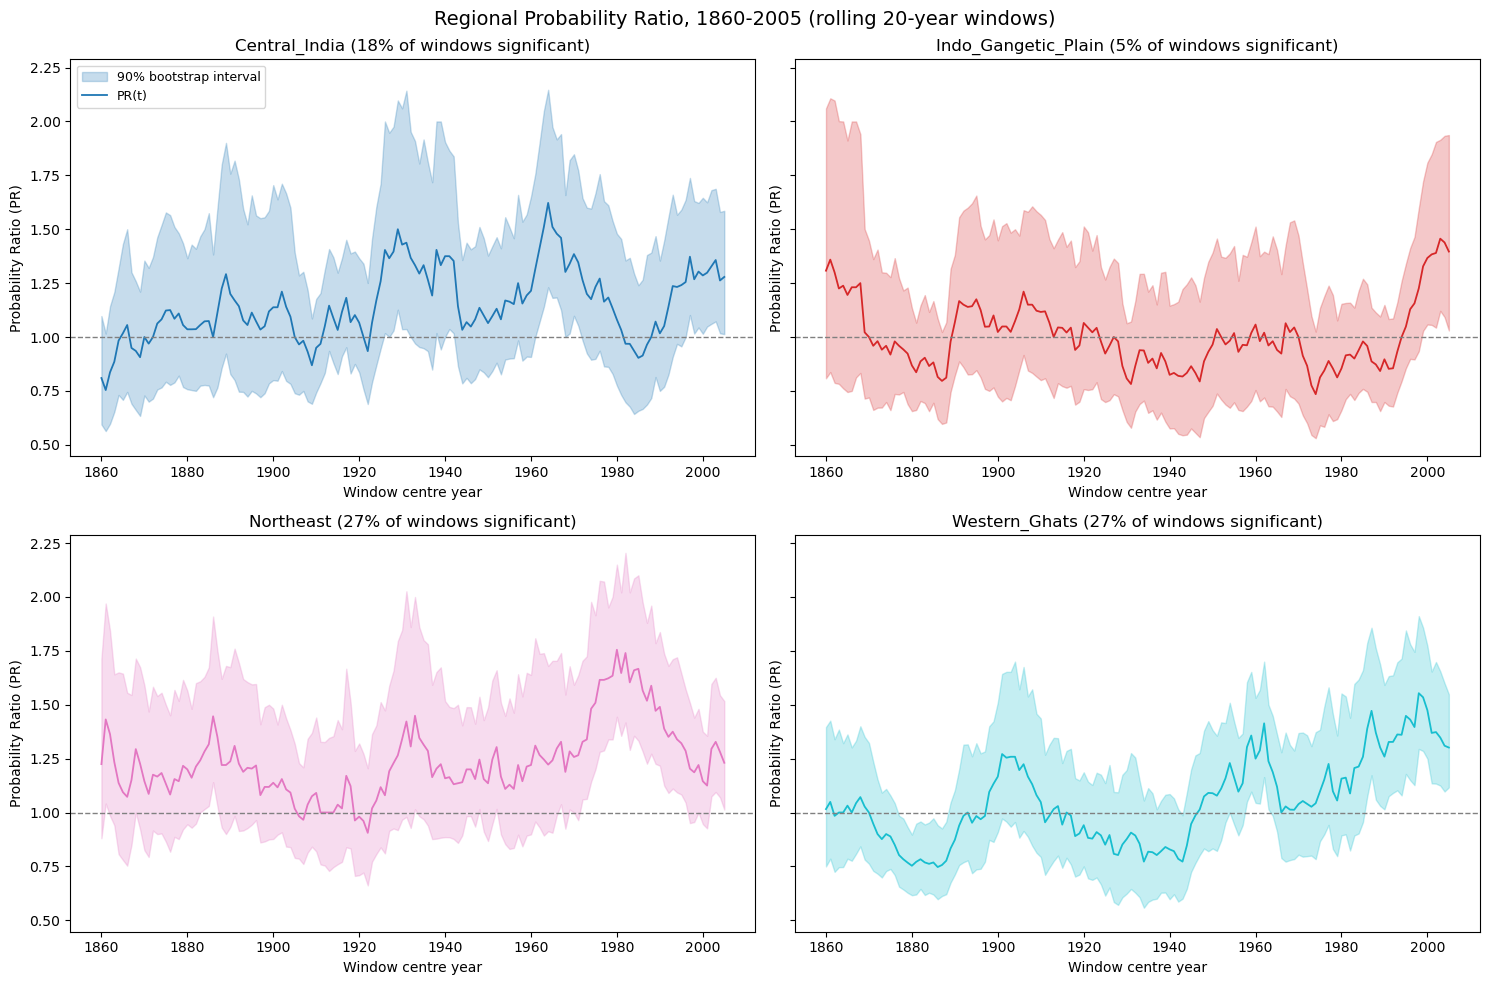

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)

region_colors = {
    'Central_India': '#1f77b4',
    'Indo_Gangetic_Plain': '#d62728',
    'Northeast': '#e377c2',
    'Western_Ghats': '#17becf',
}

for ax, region in zip(axes.flat, REGION_ORDER):
    sub = pr_df[pr_df.region == region].sort_values('year')
    color = region_colors[region]

    ax.fill_between(sub['year'], sub['PR_boot_5'], sub['PR_boot_95'],
                     alpha=0.25, color=color, label='90% bootstrap interval')
    ax.plot(sub['year'], sub['PR'], color=color, linewidth=1.3, label='PR(t)')
    ax.axhline(1, color='grey', linestyle='--', linewidth=1)

    pct_sig = sub['significant'].mean() * 100
    ax.set_title(f'{region} ({pct_sig:.0f}% of windows significant)')
    ax.set_xlabel('Window centre year')
    ax.set_ylabel('Probability Ratio (PR)')

axes.flat[0].legend(fontsize=9, loc='upper left')
fig.suptitle('Regional Probability Ratio, 1860-2005 (rolling 20-year windows)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'pr_far_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 7: Save Summary Parameters</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves a per-region summary of the PR/FAR attribution results: R0 threshold, PR range, mean PR, fraction of statistically significant windows, and the most recent window's PR/FAR values, for quick reference in the dissertation write-up.</p>
</div>

In [14]:
summary_records = []
for region in REGION_ORDER:
    sub = pr_df[pr_df.region == region].sort_values('year')
    latest = sub.iloc[-1]
    summary_records.append({
        'region': region,
        'R0_mm': R0[region],
        'PR_mean': sub['PR'].mean(),
        'PR_min': sub['PR'].min(),
        'PR_max': sub['PR'].max(),
        'pct_windows_significant': sub['significant'].mean() * 100,
        'latest_window_year': latest['year'],
        'latest_PR': latest['PR'],
        'latest_FAR': latest['FAR'],
        'latest_significant': latest['significant'],
    })

summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(OUTPUT_DIR + 'pr_far_summary_parameters.csv', index=False)
print(summary_df)

                region       R0_mm   PR_mean    PR_min    PR_max  \
0        Central_India  131.265237  1.149982  0.753846  1.622222   
1  Indo_Gangetic_Plain  110.560981  1.002851  0.734694  1.456140   
2            Northeast  164.324668  1.238049  0.905660  1.755102   
3        Western_Ghats  104.430870  1.051502  0.746988  1.553571   

   pct_windows_significant  latest_window_year  latest_PR  latest_FAR  \
0                17.808219                2005   1.278689    0.217949   
1                 4.794521                2005   1.396552    0.283951   
2                26.712329                2005   1.230769    0.187500   
3                26.712329                2005   1.301370    0.231579   

   latest_significant  
0                True  
1                True  
2                True  
3                True  


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 8: Save Windowed Sample Distributions</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves the pooled 600-sample distribution per window per region for both forcing worlds, matching the ant/nat file separation used elsewhere in the pipeline. These are the exact samples used to compute PR(t)/FAR(t) in Part 2, retained as direct input to the f(R) propagation step in Section 3.7, per the Structure Draft.</p>
</div>

In [15]:
try:
    check_ant.close()
    check_nat.close()
except NameError:
    pass
print("Closed any open file handles")

Closed any open file handles


In [16]:
def build_windowed_samples(ds, varname):
    n_windows = len(centre_years)
    n_regions = len(REGION_ORDER)
    n_samples = 600  # 30 members x 20 years

    arr = np.full((n_windows, n_regions, n_samples), np.nan)

    for w_idx, t in enumerate(centre_years):
        for region_idx in range(n_regions):
            window = ds[varname].isel(region=region_idx).sel(
                year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()
            assert len(window) == n_samples, f"Unexpected sample count at t={t}: {len(window)}"
            arr[w_idx, region_idx, :] = window

    return xr.DataArray(
        arr,
        dims=['window_centre_year', 'region', 'sample'],
        coords={'window_centre_year': centre_years, 'region': REGION_ORDER, 'sample': np.arange(n_samples)}
    )

ant_samples_da = build_windowed_samples(rx5day_ant, 'rx5day_ant_regional')
nat_samples_da = build_windowed_samples(rx5day_nat, 'rx5day_nat_regional')

ant_samples_da.to_dataset(name='rx5day_ant_windowed').to_netcdf(OUTPUT_DIR + 'pr_far_windowed_samples_ant.nc')
nat_samples_da.to_dataset(name='rx5day_nat_windowed').to_netcdf(OUTPUT_DIR + 'pr_far_windowed_samples_nat.nc')

print("Saved both windowed sample files.")
print(ant_samples_da.shape, nat_samples_da.shape)

Saved both windowed sample files.
(146, 4, 600) (146, 4, 600)


In [17]:
check_ant = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_ant.nc')
check_nat = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_nat.nc')

print(check_ant)
print()
print(check_nat.window_centre_year.values[:5], "...", check_nat.window_centre_year.values[-5:])

<xarray.Dataset> Size: 3MB
Dimensions:              (window_centre_year: 146, region: 4, sample: 600)
Coordinates:
  * window_centre_year   (window_centre_year) int64 1kB 1860 1861 ... 2004 2005
  * region               (region) <U19 304B 'Central_India' ... 'Western_Ghats'
  * sample               (sample) int64 5kB 0 1 2 3 4 5 ... 595 596 597 598 599
Data variables:
    rx5day_ant_windowed  (window_centre_year, region, sample) float64 3MB ...

[1860 1861 1862 1863 1864] ... [2001 2002 2003 2004 2005]


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Summary (Preliminary: Average-First Method)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Preliminary regional PR/FAR time series computed via the average-first Kharin-Zwiers rolling-window method, spanning window centres 1860-2005. This version is superseded by the PR-first method validated in the diagnostic sections below and reported in the dissertation (Section 5.4-5.5, Figure 17) - retained here as the baseline against which that validation is performed, not as the final result.</p>
</div>

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Diagnostic 1: Single Grid-Cell PR vs Regional-Average PR</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">The regional PR(t) curves for Northeast, Central India, and Indo-Gangetic Plain don't approach PR=1 in the earliest windows, as physically expected before meaningful anthropogenic forcing. Averaging Rx5day, itself an extreme-value statistic, across grid cells before computing exceedances may distort the exceedance count near the R0 threshold, independent of any real anthropogenic signal. This mirrors the approach in Zhao et al. (2025), which avoided regional averaging of extremes entirely, working grid-cell by grid-cell instead. To test this, PR(t) is recomputed here using a single representative grid cell per region (highest fractional regional weight), following the exact same method as the regional-average version, and compared directly against the existing regional-average PR(t) curves from earlier in this notebook.</p>
</div>

In [20]:
rx5day_ant_grid = xr.open_dataarray(OUTPUT_DIR + 'rx5day_jjas_ant_all.nc')
rx5day_nat_grid = xr.open_dataarray(OUTPUT_DIR + 'rx5day_jjas_nat_all.nc')

In [ ]:
import geopandas as gpd
import regionmask

# Rebuild region masks - same definitions as notebooks 04/09/10
path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}

state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

region_names = gdf_regions.index.tolist()
regions_mask_obj = regionmask.Regions(
    gdf_regions.geometry.tolist(),
    names=region_names,
    abbrevs=[r[:3] for r in region_names]
)

# Project onto MPI-GE's grid (same lat/lon as rx5day_ant_grid)
frac_overlap_mpi = regions_mask_obj.mask_3D_frac_approx(
    rx5day_ant_grid.lon.values, rx5day_ant_grid.lat.values
)

# Ensure region coordinate is named (not just integer-indexed)
frac_overlap_mpi = frac_overlap_mpi.assign_coords(region=region_names)

print('Region masks rebuilt on MPI-GE grid')
print(f'Regions: {region_names}')

Region masks rebuilt on MPI-GE grid
Regions: ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']


In [22]:
rep_cells = {}
for region in REGION_ORDER:
    weights = frac_overlap_mpi.sel(region=region)
    max_idx = weights.argmax(dim=['lat', 'lon'])
    rep_lat = float(weights.lat[max_idx['lat']])
    rep_lon = float(weights.lon[max_idx['lon']])
    rep_cells[region] = (rep_lat, rep_lon)
    print(f'{region}: representative cell at lat={rep_lat:.2f}, lon={rep_lon:.2f}, weight={float(weights.max()):.2f}')

Central_India: representative cell at lat=21.45, lon=82.50, weight=1.00
Indo_Gangetic_Plain: representative cell at lat=27.05, lon=80.62, weight=1.00
Northeast: representative cell at lat=27.05, lon=93.75, weight=0.93
Western_Ghats: representative cell at lat=15.85, lon=75.00, weight=1.00


In [23]:
BASELINE_START, BASELINE_END = 1981, 2010

def compute_PR_gridcell(lat_val, lon_val):
    ant_cell = rx5day_ant_grid.sel(lat=lat_val, lon=lon_val, method='nearest')
    nat_cell = rx5day_nat_grid.sel(lat=lat_val, lon=lon_val, method='nearest')

    # R0: 90th percentile of THIS grid cell's Hist-NAT 1981-2010 baseline (same method, single cell)
    nat_baseline = nat_cell.sel(year=slice(BASELINE_START, BASELINE_END)).values.flatten()
    R0_cell = np.percentile(nat_baseline, 90)

    results = []
    for t in centre_years:
        ant_window = ant_cell.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()
        nat_window = nat_cell.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()

        P_ant = np.mean(ant_window > R0_cell)
        P_nat = np.mean(nat_window > R0_cell)
        PR = P_ant / P_nat if P_nat > 0 else np.nan
        results.append({'year': t, 'PR': PR})

    return pd.DataFrame(results), R0_cell

gridcell_results = {}
for region in REGION_ORDER:
    lat_val, lon_val = rep_cells[region]
    df, R0_cell = compute_PR_gridcell(lat_val, lon_val)
    gridcell_results[region] = df
    print(f'{region}: R0 (grid cell) = {R0_cell:.1f} mm')

Central_India: R0 (grid cell) = 154.7 mm
Indo_Gangetic_Plain: R0 (grid cell) = 109.6 mm
Northeast: R0 (grid cell) = 206.3 mm
Western_Ghats: R0 (grid cell) = 96.0 mm


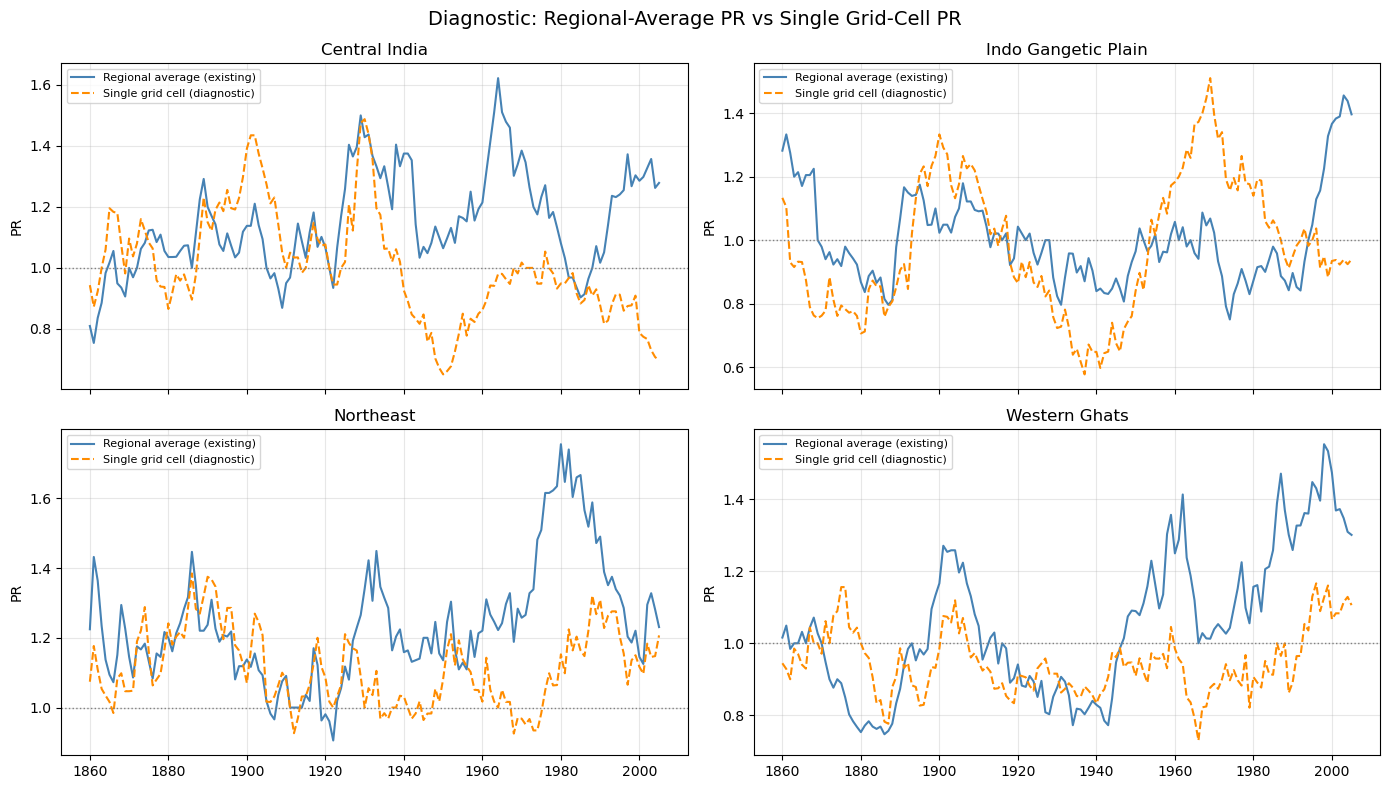

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]

    regional = pr_df[pr_df.region == region].sort_values('year')
    ax.plot(regional.year, regional.PR, label='Regional average (existing)', color='steelblue')

    cell = gridcell_results[region]
    ax.plot(cell.year, cell.PR, label='Single grid cell (diagnostic)', color='darkorange', linestyle='--')

    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_title(region.replace('_', ' '))
    ax.set_ylabel('PR')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Diagnostic: Regional-Average PR vs Single Grid-Cell PR', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'diagnostic_gridcell_vs_regional_PR.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Diagnostic 2: Order of Operations on a Non-Extreme Statistic</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Diagnostic 1 showed spatial averaging can distort exceedance-based statistics, but Rx5day is itself already an extreme-value statistic. This repeats the regional-average vs single-grid-cell comparison using JJAS-mean daily precipitation instead, a non-extreme quantity, to test whether the divergence is specific to averaging extremes or occurs for ordinary rainfall statistics too.</p>
</div>

In [25]:
import glob, os

HIST_PATH = '/data/oacd/smiles/MPI/historical/pr_day/'
NAT_PATH = '/data/oacd/smiles/MPI/hist-nat/pr_day/'
MEMBERS = [f'r{i}i1p1f1' for i in range(1, 31)]
LAT_MIN, LAT_MAX = 8, 35
LON_MIN, LON_MAX = 68, 99
JJAS = [6, 7, 8, 9]

def extract_jjas_mean(member, base_path):
    """JJAS-mean daily precip per grid cell per year (NOT an extreme statistic)."""
    files = sorted(glob.glob(os.path.join(base_path, f'*{member}*.nc')))
    if len(files) == 0:
        raise FileNotFoundError(f'No files for {member} in {base_path}')
    ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time': 365})
    pr = (ds['pr'] * 86400).sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    pr_jjas = pr.sel(time=pr.time.dt.month.isin(JJAS))
    # Seasonal MEAN per year (contrast with Rx5day's annual max of rolling sum)
    jjas_mean = pr_jjas.groupby('time.year').mean(dim='time')
    return jjas_mean

def build_forcing_meanprecip(base_path, label):
    print(f'Extracting JJAS-mean precip: {label}...')
    all_members = []
    for m in MEMBERS:
        all_members.append(extract_jjas_mean(m, base_path))
        print(f'  {m} done')
    stacked = xr.concat(all_members, dim='member').assign_coords(member=MEMBERS).compute()
    return stacked

meanpr_ant_grid = build_forcing_meanprecip(HIST_PATH, 'anthropogenic')
meanpr_nat_grid = build_forcing_meanprecip(NAT_PATH, 'natural')

print('Shapes:', dict(meanpr_ant_grid.sizes), dict(meanpr_nat_grid.sizes))

Extracting JJAS-mean precip: anthropogenic...
  r1i1p1f1 done
  r2i1p1f1 done
  r3i1p1f1 done
  r4i1p1f1 done
  r5i1p1f1 done
  r6i1p1f1 done
  r7i1p1f1 done
  r8i1p1f1 done
  r9i1p1f1 done
  r10i1p1f1 done
  r11i1p1f1 done
  r12i1p1f1 done
  r13i1p1f1 done
  r14i1p1f1 done
  r15i1p1f1 done
  r16i1p1f1 done
  r17i1p1f1 done
  r18i1p1f1 done
  r19i1p1f1 done
  r20i1p1f1 done
  r21i1p1f1 done
  r22i1p1f1 done
  r23i1p1f1 done
  r24i1p1f1 done
  r25i1p1f1 done
  r26i1p1f1 done
  r27i1p1f1 done
  r28i1p1f1 done
  r29i1p1f1 done
  r30i1p1f1 done


KeyboardInterrupt: 

In [26]:
meanpr_ant_grid.to_dataset(name='meanpr_ant_grid').to_netcdf(OUTPUT_DIR + 'meanpr_ant_grid_diagnostic2.nc')
meanpr_nat_grid.to_dataset(name='meanpr_nat_grid').to_netcdf(OUTPUT_DIR + 'meanpr_nat_grid_diagnostic2.nc')
print('Saved Diagnostic 2 mean-precip grids for reuse')

NameError: name 'meanpr_ant_grid' is not defined

In [27]:
meanpr_ant_grid = xr.open_dataset(OUTPUT_DIR + 'meanpr_ant_grid_diagnostic2.nc')['meanpr_ant_grid']
meanpr_nat_grid = xr.open_dataset(OUTPUT_DIR + 'meanpr_nat_grid_diagnostic2.nc')['meanpr_nat_grid']
print('Loaded Diagnostic 2 mean-precip grids from disk')

Loaded Diagnostic 2 mean-precip grids from disk


In [28]:
# Regional-average mean-precip series (Approach A: area-weighted mean across cells)
# Reuse frac_overlap_mpi from the earlier diagnostic (already on MPI grid)
def regional_average(grid_da):
    valid = grid_da.notnull()
    wsum = (grid_da * frac_overlap_mpi).sum(dim=['lat', 'lon'], skipna=True)
    wtot = frac_overlap_mpi.where(valid).sum(dim=['lat', 'lon'], skipna=True)
    return wsum / wtot  # dims: (member, year, region)

meanpr_ant_regional = regional_average(meanpr_ant_grid)
meanpr_nat_regional = regional_average(meanpr_nat_grid)

BASELINE_START, BASELINE_END = 1981, 2010

def compute_PR_series(ant_da, nat_da, R0_val):
    """PR(t) for a series with dims (member, year), given a fixed R0."""
    results = []
    for t in centre_years:
        ant_w = ant_da.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()
        nat_w = nat_da.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()
        P_ant = np.mean(ant_w > R0_val)
        P_nat = np.mean(nat_w > R0_val)
        PR = P_ant / P_nat if P_nat > 0 else np.nan
        results.append({'year': t, 'PR': PR})
    return pd.DataFrame(results)

meanpr_regional_PR = {}
for i, region in enumerate(REGION_ORDER):
    ant_r = meanpr_ant_regional.sel(region=region)
    nat_r = meanpr_nat_regional.sel(region=region)
    nat_base = nat_r.sel(year=slice(BASELINE_START, BASELINE_END)).values.flatten()
    R0_r = np.percentile(nat_base, 90)
    meanpr_regional_PR[region] = compute_PR_series(ant_r, nat_r, R0_r)
    print(f'{region}: regional mean-precip R0 = {R0_r:.2f} mm/day')

# Single-cell PR (mean precip), same representative cells as before
meanpr_gridcell_PR = {}
for region in REGION_ORDER:
    lat_val, lon_val = rep_cells[region]
    ant_c = meanpr_ant_grid.sel(lat=lat_val, lon=lon_val, method='nearest')
    nat_c = meanpr_nat_grid.sel(lat=lat_val, lon=lon_val, method='nearest')
    nat_base = nat_c.sel(year=slice(BASELINE_START, BASELINE_END)).values.flatten()
    R0_c = np.percentile(nat_base, 90)
    meanpr_gridcell_PR[region] = compute_PR_series(ant_c, nat_c, R0_c)
    print(f'{region}: single-cell mean-precip R0 = {R0_c:.2f} mm/day')

Central_India: regional mean-precip R0 = 8.65 mm/day
Indo_Gangetic_Plain: regional mean-precip R0 = 5.95 mm/day
Northeast: regional mean-precip R0 = 12.67 mm/day
Western_Ghats: regional mean-precip R0 = 5.90 mm/day
Central_India: single-cell mean-precip R0 = 10.96 mm/day
Indo_Gangetic_Plain: single-cell mean-precip R0 = 4.88 mm/day
Northeast: single-cell mean-precip R0 = 14.95 mm/day
Western_Ghats: single-cell mean-precip R0 = 4.34 mm/day


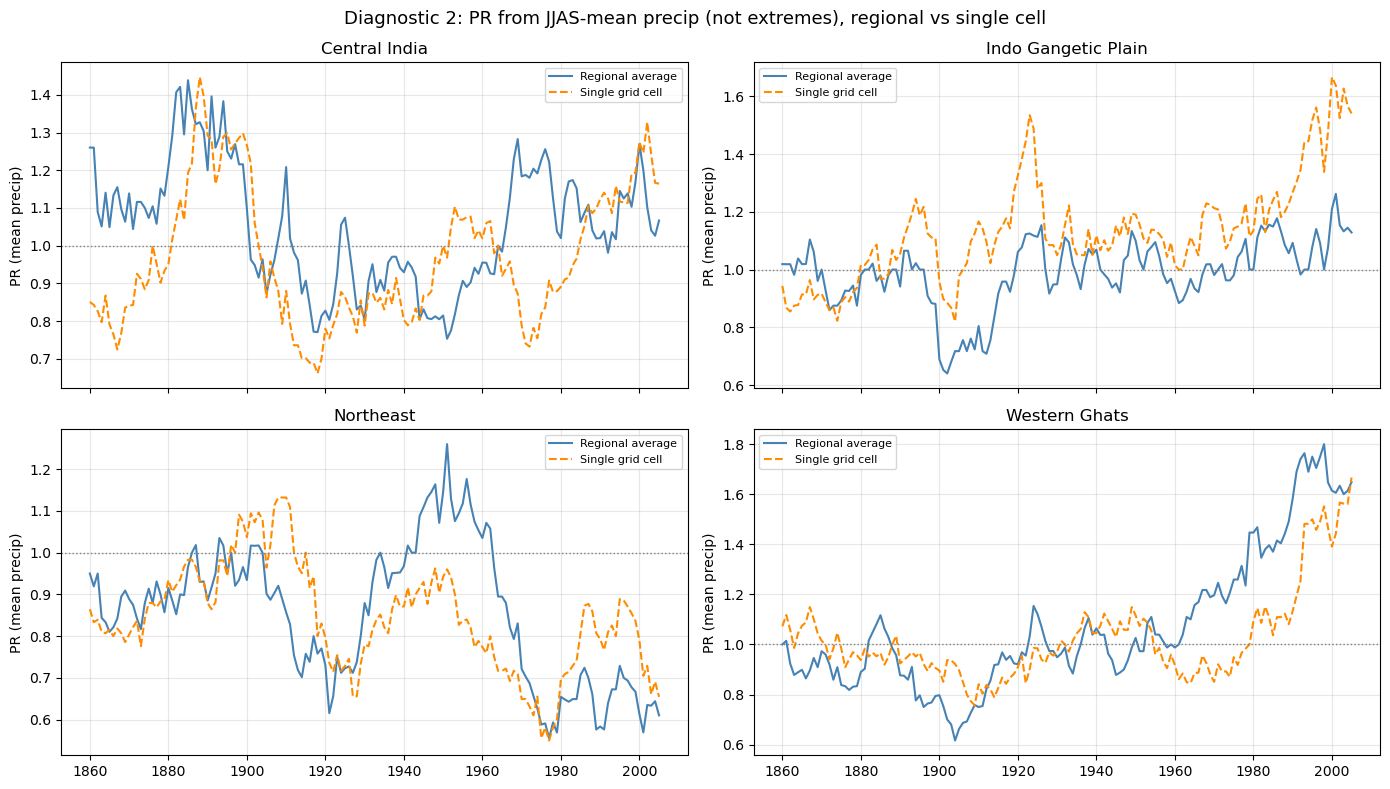

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    reg = meanpr_regional_PR[region]
    cell = meanpr_gridcell_PR[region]
    ax.plot(reg.year, reg.PR, label='Regional average', color='steelblue')
    ax.plot(cell.year, cell.PR, label='Single grid cell', color='darkorange', linestyle='--')
    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_title(region.replace('_', ' '))
    ax.set_ylabel('PR (mean precip)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Diagnostic 2: PR from JJAS-mean precip (not extremes), regional vs single cell', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'diagnostic2_meanprecip_PR.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Diagnostic 3: Threshold Sensitivity</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Tests whether the choice of R0 (fixed at the 90th percentile throughout this notebook) affects the regional PR(t) pattern, by recomputing the regional-average PR(t) at the 90th, 75th, and 50th percentile thresholds and comparing their trajectories.</p>
</div>

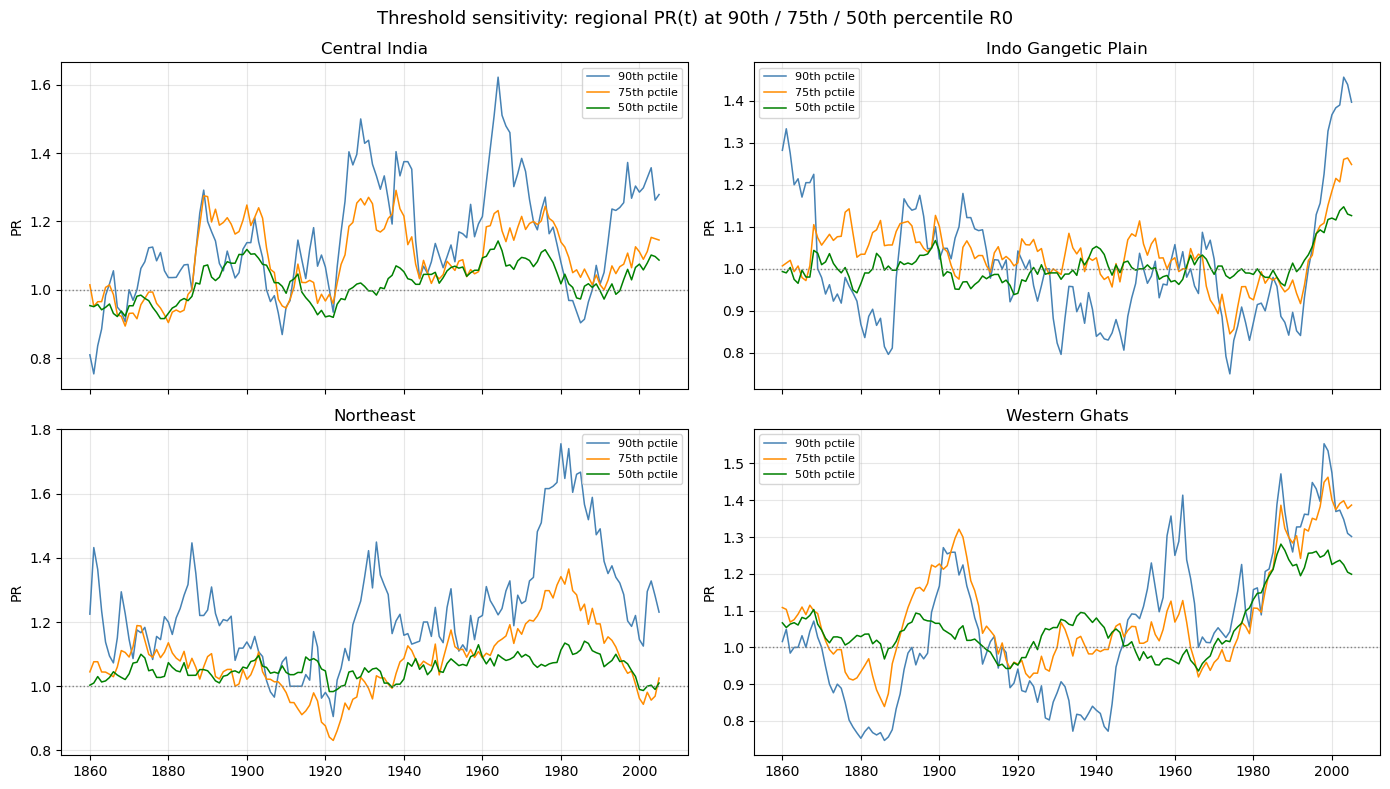

In [30]:
THRESHOLDS = [90, 75, 50]
threshold_colors = {90: 'steelblue', 75: 'darkorange', 50: 'green'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    region_idx = REGION_ORDER.index(region)

    for pct in THRESHOLDS:
        # R0 at this percentile, from Hist-NAT 1981-2010 baseline (regional-average series)
        nat_base = rx5day_nat['rx5day_nat_regional'].isel(region=region_idx).sel(
            year=slice(1981, 2010)).values.flatten()
        R0_pct = np.percentile(nat_base, pct)

        prs = []
        for t in centre_years:
            ant_w = rx5day_ant['rx5day_ant_regional'].isel(region=region_idx).sel(
                year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()
            nat_w = rx5day_nat['rx5day_nat_regional'].isel(region=region_idx).sel(
                year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values.flatten()
            P_ant = np.mean(ant_w > R0_pct)
            P_nat = np.mean(nat_w > R0_pct)
            prs.append(P_ant / P_nat if P_nat > 0 else np.nan)

        ax.plot(centre_years, prs, label=f'{pct}th pctile', color=threshold_colors[pct], linewidth=1.1)

    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_title(region.replace('_', ' '))
    ax.set_ylabel('PR')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Threshold sensitivity: regional PR(t) at 90th / 75th / 50th percentile R0', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'diagnostic3_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Diagnostic 4: Order of Operations, Average-First vs PR-First</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">An's hypothesis was that area-averaging Rx5day (an extreme-value statistic) before computing exceedances distorts the PR calculation. This tests it by comparing two orders of operation: (1) AVERAGE-FIRST: area-average Rx5day across grid cells into one regional series, then compute a single PR(t) versus (2) PR-FIRST: compute PR(t) independently at every grid cell, then area-average those per-cell PR values into a regional PR(t). If the two curves are similar, averaging order does not materially affect the result and the existing method is sound. If they differ, particularly if PR-first sits closer to 1.0 in the early record, that would suggest the average-first approach distorts the extreme-value statistics.</p>
</div>

In [32]:
# Fixed 90th-percentile R0 at every grid cell, from Hist-NAT 1981-2010 baseline
nat_baseline_grid = rx5day_nat_grid.sel(year=slice(1981, 2010))  # (member, year, lat, lon)
R0_grid = nat_baseline_grid.quantile(0.90, dim=['member', 'year'])  # (lat, lon)
print('Per-cell R0 grid computed, shape:', dict(R0_grid.sizes))
print(f'R0 range across cells: {float(R0_grid.min()):.1f} to {float(R0_grid.max()):.1f} mm')

Per-cell R0 grid computed, shape: {'lat': 15, 'lon': 16}
R0 range across cells: 33.2 to 414.7 mm


In [33]:
R0_grid.to_dataset(name='R0_grid').to_netcdf(OUTPUT_DIR + 'R0_grid.nc')
frac_overlap_mpi.to_dataset(name='frac_overlap_mpi').to_netcdf(OUTPUT_DIR + 'frac_overlap_mpi.nc')
print('Saved R0_grid and frac_overlap_mpi for downstream reuse')

Saved R0_grid and frac_overlap_mpi for downstream reuse


In [34]:
# Per-cell PR(t): for each window, exceedance fraction vs that cell's own R0, ant / nat
# Vectorised across the whole lat/lon grid at once for speed.

def per_cell_PR_timeseries(ant_grid, nat_grid, R0_grid, centre_years):
    pr_stack = []
    for t in centre_years:
        ant_w = ant_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER))  # (member, 20yr, lat, lon)
        nat_w = nat_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER))

        # fraction of (member x year) samples exceeding R0, per cell
        P_ant = (ant_w > R0_grid).mean(dim=['member', 'year'])  # (lat, lon)
        P_nat = (nat_w > R0_grid).mean(dim=['member', 'year'])

        PR_cell = xr.where(P_nat > 0, P_ant / P_nat, np.nan)  # (lat, lon)
        PR_cell = PR_cell.assign_coords(year=t)
        pr_stack.append(PR_cell)

    return xr.concat(pr_stack, dim='year')  # (year, lat, lon)

PR_per_cell = per_cell_PR_timeseries(rx5day_ant_grid, rx5day_nat_grid, R0_grid, list(centre_years))
print('Per-cell PR time series computed, shape:', dict(PR_per_cell.sizes))

Per-cell PR time series computed, shape: {'year': 146, 'lat': 15, 'lon': 16}


In [35]:
# Save PR_per_cell so it doesn't need recomputing on kernel restart
PR_per_cell.to_dataset(name='PR_per_cell').to_netcdf(OUTPUT_DIR + 'PR_per_cell.nc')
print('Saved PR_per_cell for reuse')

Saved PR_per_cell for reuse


In [36]:
# Load from disk instead of recomputing (use this after a kernel restart)
PR_per_cell = xr.open_dataset(OUTPUT_DIR + 'PR_per_cell.nc')['PR_per_cell']
print('Loaded PR_per_cell from disk, shape:', dict(PR_per_cell.sizes))

Loaded PR_per_cell from disk, shape: {'year': 146, 'lat': 15, 'lon': 16}


In [37]:
# Area-average the per-cell PR values into a regional PR-first series
# Same fractional weights as everywhere else; skipping NaN cells (where P_nat was 0)
def area_average_PR(pr_grid, region):
    weights = frac_overlap_mpi.sel(region=region)  # (lat, lon)
    valid = pr_grid.notnull()
    wsum = (pr_grid * weights).sum(dim=['lat', 'lon'], skipna=True)
    wtot = weights.where(valid).sum(dim=['lat', 'lon'], skipna=True)
    return wsum / wtot  # (year,)

pr_first = {}
for region in REGION_ORDER:
    pr_first[region] = area_average_PR(PR_per_cell, region)

print('PR-first regional series computed for all regions')

PR-first regional series computed for all regions


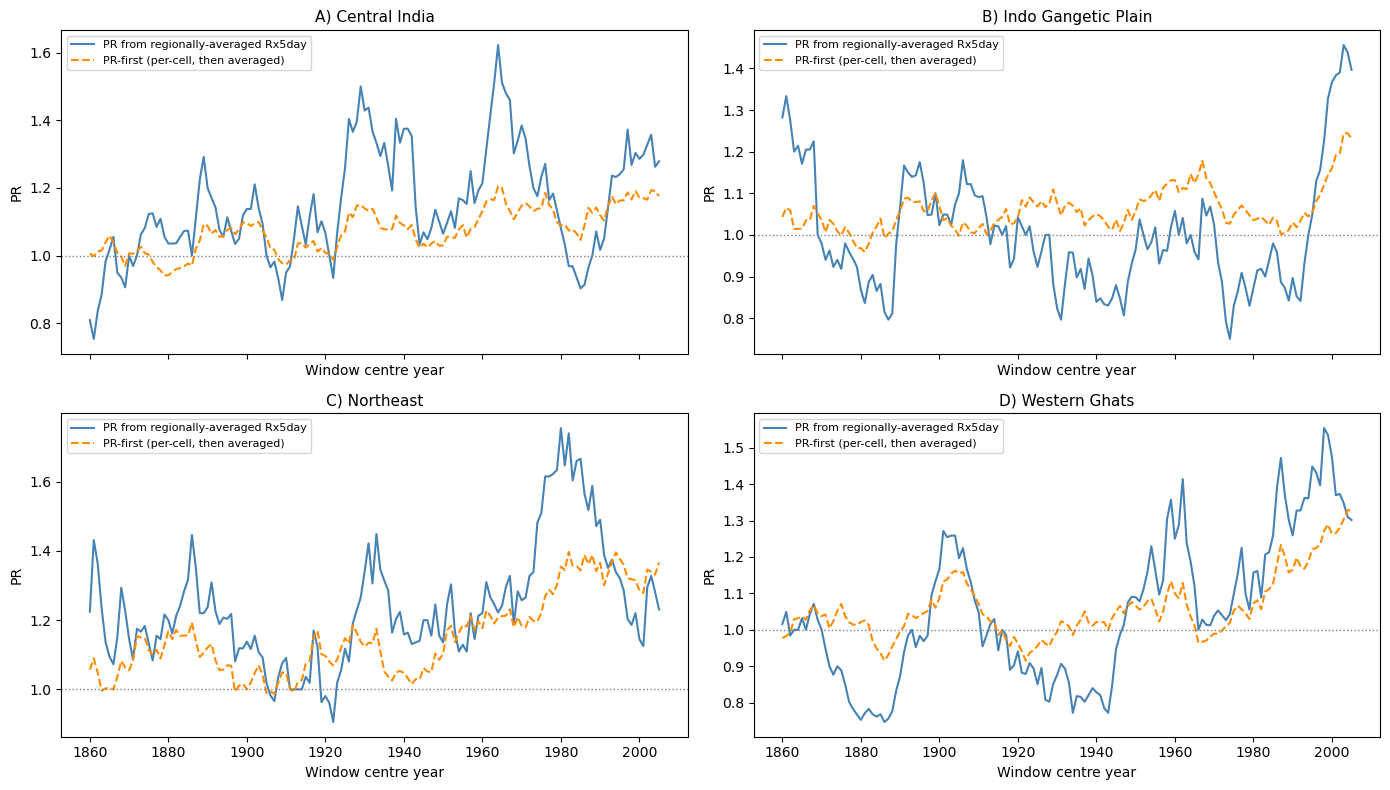

In [48]:
# Compare: average-first (existing pr_df) vs PR-first (new)
panel_letters = ['A)', 'B)', 'C)', 'D)']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    avg_first = pr_df[pr_df.region == region].sort_values('year')
    ax.plot(avg_first.year, avg_first.PR, label='PR from regionally-averaged Rx5day', color='steelblue')
    pf = pr_first[region]
    ax.plot(pf.year, pf.values, label='PR-first (per-cell, then averaged)', color='darkorange', linestyle='--')
    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'{panel_letters[i]} {region.replace("_", " ")}', fontsize=11)
    ax.set_ylabel('PR')
    ax.set_xlabel('Window centre year')
    ax.legend(fontsize=8)

plt.tight_layout()
# Reported in the dissertation as Figure 14
plt.savefig(OUTPUT_DIR + 'diagnostic4_avgfirst_vs_prfirst.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Diagnostic 5: Non-Overlapping Blocks</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Adjacent 20-year rolling windows share roughly 95% of their observations, so the smooth PR(t) trajectory could partly reflect this overlap rather than a genuine temporal signal. This recomputes PR using independent, non-overlapping 20-year blocks and compares the result against the rolling PR-first curve from Diagnostic 4.</p>
</div>

In [39]:
# Non-overlapping 20-year blocks across the full record (matches Kirchmeier-Young & Zhang precedent)
block_starts = list(range(1850, 2015, 20))
block_centres = [s + 10 for s in block_starts if s + 19 <= 2014]

print(f'{len(block_centres)} non-overlapping blocks, centred: {block_centres}')

# Reuse R0_grid and PR_per_cell machinery (per-cell PR, then area-average), PR-first method
def per_cell_PR_block(ant_grid, nat_grid, R0_grid, block_start):
    ant_b = ant_grid.sel(year=slice(block_start, block_start + 19))
    nat_b = nat_grid.sel(year=slice(block_start, block_start + 19))
    P_ant = (ant_b > R0_grid).mean(dim=['member', 'year'])
    P_nat = (nat_b > R0_grid).mean(dim=['member', 'year'])
    return xr.where(P_nat > 0, P_ant / P_nat, np.nan)

block_PR_first = {region: [] for region in REGION_ORDER}
for s in block_starts:
    if s + 19 > 2014:
        continue
    PR_cell_block = per_cell_PR_block(rx5day_ant_grid, rx5day_nat_grid, R0_grid, s)
    for region in REGION_ORDER:
        weights = frac_overlap_mpi.sel(region=region)
        valid = PR_cell_block.notnull()
        wsum = (PR_cell_block * weights).sum(dim=['lat', 'lon'], skipna=True)
        wtot = weights.where(valid).sum(dim=['lat', 'lon'], skipna=True)
        block_PR_first[region].append(float(wsum / wtot))

print('Non-overlapping block PR (PR-first method):')
for region in REGION_ORDER:
    print(f'{region}: {[round(v,3) for v in block_PR_first[region]]}')

8 non-overlapping blocks, centred: [1860, 1880, 1900, 1920, 1940, 1960, 1980, 2000]
Non-overlapping block PR (PR-first method):
Central_India: [1.006, 0.942, 1.097, 1.008, 1.089, 1.131, 1.089, 1.171]
Indo_Gangetic_Plain: [1.043, 0.968, 1.069, 1.042, 1.05, 1.131, 1.035, 1.16]
Northeast: [1.057, 1.168, 1.0, 1.097, 1.048, 1.177, 1.355, 1.286]
Western_Ghats: [0.977, 1.022, 1.086, 0.963, 1.021, 1.099, 1.073, 1.264]


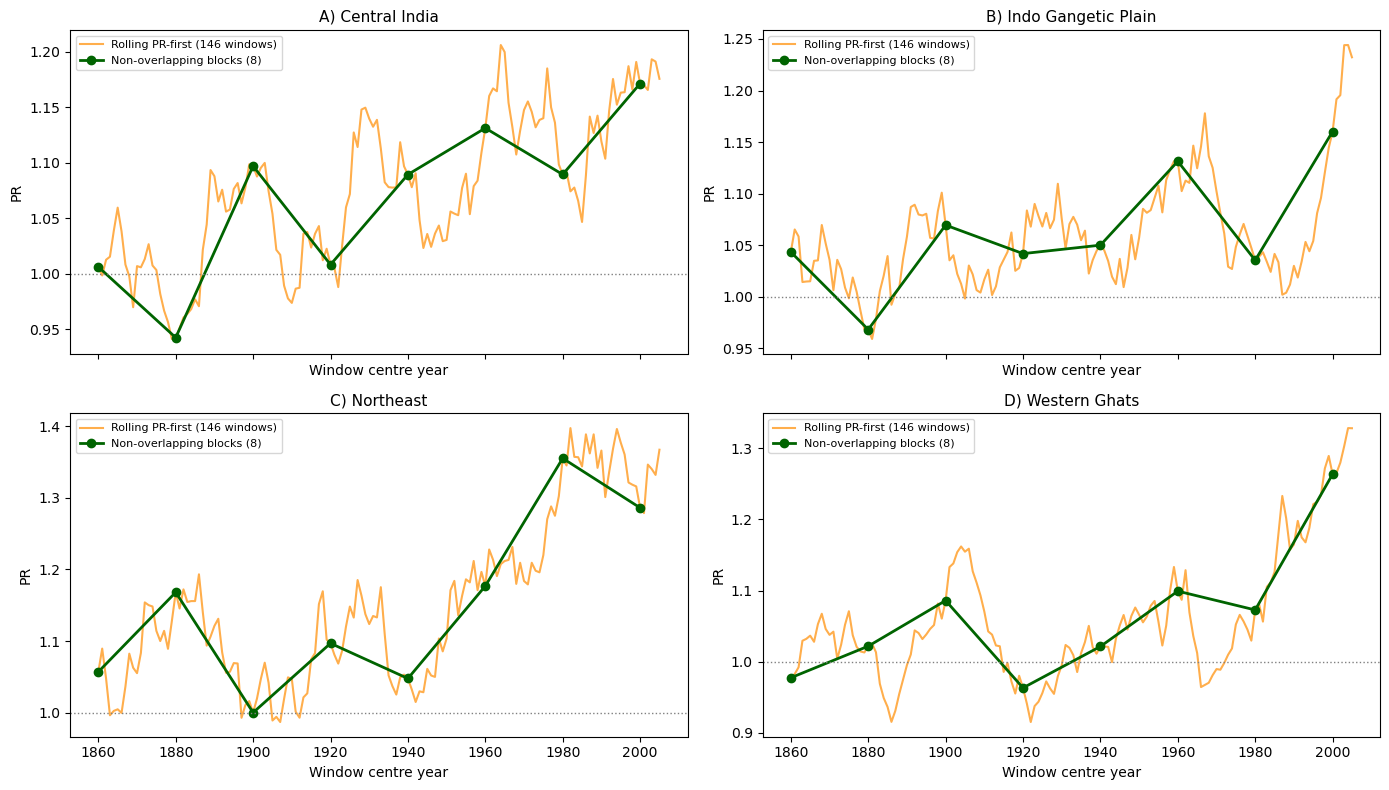

In [49]:
panel_letters = ['A)', 'B)', 'C)', 'D)']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    pf = pr_first[region]
    ax.plot(pf.year, pf.values, label='Rolling PR-first (146 windows)', color='darkorange', alpha=0.7)
    ax.plot(block_centres, block_PR_first[region], 'o-', label='Non-overlapping blocks (8)',
             color='darkgreen', linewidth=2, markersize=6)
    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'{panel_letters[i]} {region.replace("_", " ")}', fontsize=11)
    ax.set_ylabel('PR')
    ax.set_xlabel('Window centre year')
    ax.legend(fontsize=8)

plt.tight_layout()
# Reported in the dissertation as Figure 16
plt.savefig(OUTPUT_DIR + 'diagnostic5_rolling_vs_blocks.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Diagnostic 6: Member-First vs Pooled</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Tests whether ensemble members can be treated as pooled, independent realisations. Compares PR computed by pooling all 30 members before the exceedance step (pooled, Diagnostic 4's method) against PR computed per member and then averaged (member-first). For a convex ratio statistic like PR, Jensen's inequality predicts these will diverge systematically rather than agree.</p>
</div>

In [41]:
def per_cell_member_first_PR(ant_grid, nat_grid, R0_grid, centre_years):
    """At each grid cell: compute PR per member (20 samples each), then average across members.
       Contrast with PR_per_cell (Diagnostic 4), which pools all members together per cell."""
    pr_stack = []
    for t in centre_years:
        ant_w = ant_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER))
        nat_w = nat_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER))
        P_ant_member = (ant_w > R0_grid).mean(dim='year')
        P_nat_member = (nat_w > R0_grid).mean(dim='year')
        with np.errstate(divide='ignore', invalid='ignore'):
            PR_member = xr.where(P_nat_member > 0, P_ant_member / P_nat_member, np.nan)
        PR_cell_avg = PR_member.mean(dim='member', skipna=True)  # (lat, lon), averaged across members
        PR_cell_avg = PR_cell_avg.assign_coords(year=t)
        pr_stack.append(PR_cell_avg)
    return xr.concat(pr_stack, dim='year')

PR_per_cell_memberfirst = per_cell_member_first_PR(rx5day_ant_grid, rx5day_nat_grid, R0_grid, list(centre_years))
print('Member-first per-cell PR computed, shape:', dict(PR_per_cell_memberfirst.sizes))

Member-first per-cell PR computed, shape: {'year': 146, 'lat': 15, 'lon': 16}


In [42]:
# Save PR_per_cell_memberfirst so it doesn't need recomputing on kernel restart
PR_per_cell_memberfirst.to_dataset(name='PR_per_cell_memberfirst').to_netcdf(OUTPUT_DIR + 'PR_per_cell_memberfirst.nc')
print('Saved PR_per_cell_memberfirst for reuse')

Saved PR_per_cell_memberfirst for reuse


In [43]:
member_first_spatial = {}
for region in REGION_ORDER:
    weights = frac_overlap_mpi.sel(region=region)
    valid = PR_per_cell_memberfirst.notnull()
    wsum = (PR_per_cell_memberfirst * weights).sum(dim=['lat', 'lon'], skipna=True)
    wtot = weights.where(valid).sum(dim=['lat', 'lon'], skipna=True)
    member_first_spatial[region] = wsum / wtot

print('Member-first regional series computed for all regions')

Member-first regional series computed for all regions


In [44]:
def per_cell_member_first_PR_keepmembers(ant_grid, nat_grid, R0_grid, centre_years):
    """Same as per_cell_member_first_PR, but returns per-member values (not yet averaged)."""
    pr_stack = []
    for t in centre_years:
        ant_w = ant_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER))
        nat_w = nat_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER))

        P_ant_member = (ant_w > R0_grid).mean(dim='year')  # (member, lat, lon)
        P_nat_member = (nat_w > R0_grid).mean(dim='year')

        with np.errstate(divide='ignore', invalid='ignore'):
            PR_member = xr.where(P_nat_member > 0, P_ant_member / P_nat_member, np.nan)

        PR_member = PR_member.assign_coords(year=t)
        pr_stack.append(PR_member)

    return xr.concat(pr_stack, dim='year')  # (year, member, lat, lon)

PR_per_cell_bymember = per_cell_member_first_PR_keepmembers(rx5day_ant_grid, rx5day_nat_grid, R0_grid, list(centre_years))
print('Per-member per-cell PR computed, shape:', dict(PR_per_cell_bymember.sizes))

Per-member per-cell PR computed, shape: {'year': 146, 'member': 30, 'lat': 15, 'lon': 16}


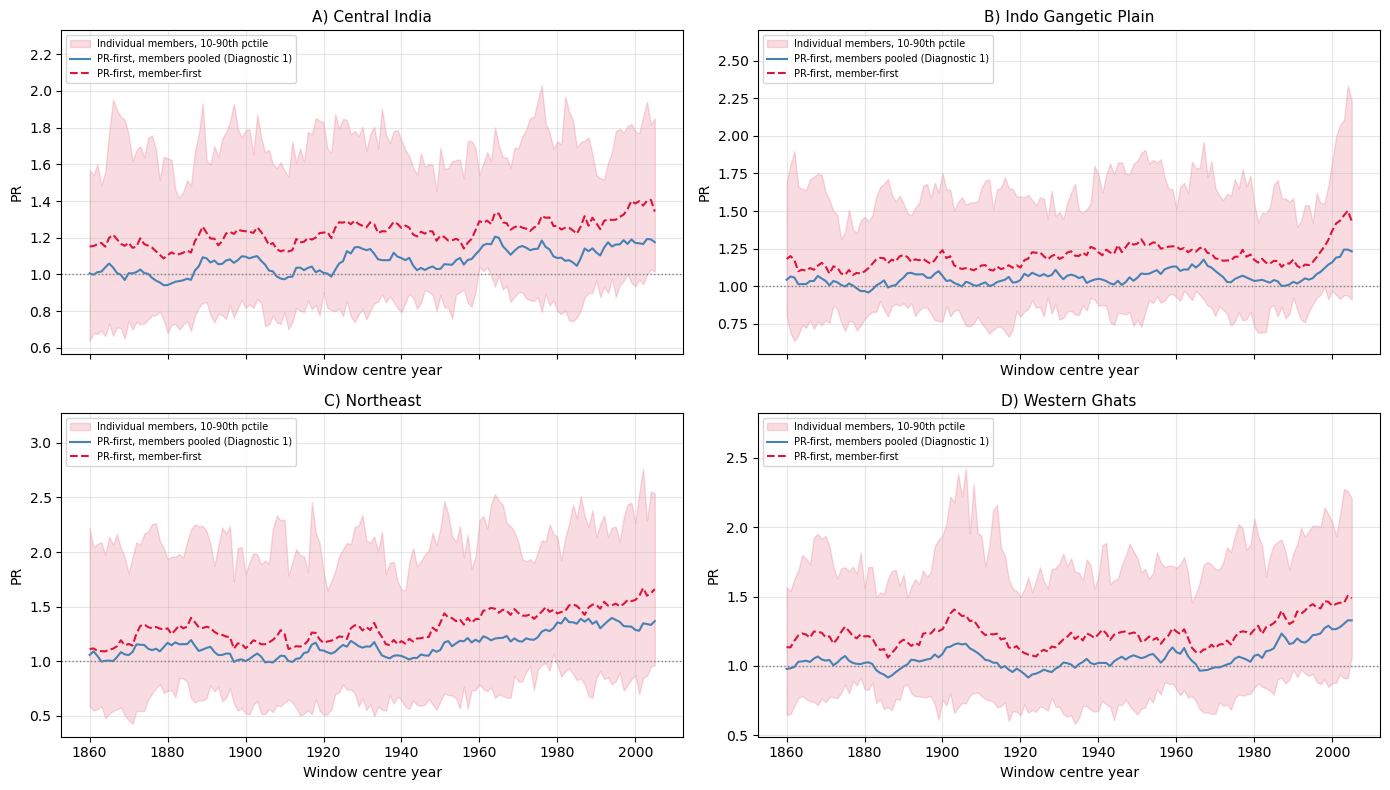

In [50]:
member_spread_regional = {}
for region in REGION_ORDER:
    weights = frac_overlap_mpi.sel(region=region)
    valid = PR_per_cell_bymember.notnull()
    wsum = (PR_per_cell_bymember * weights).sum(dim=['lat', 'lon'], skipna=True)
    wtot = weights.where(valid).sum(dim=['lat', 'lon'], skipna=True)
    member_spread_regional[region] = wsum / wtot

panel_letters = ['A)', 'B)', 'C)', 'D)']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    spread = member_spread_regional[region]
    p10 = spread.quantile(0.10, dim='member')
    p90 = spread.quantile(0.90, dim='member')
    ax.fill_between(spread.year, p10, p90, color='crimson', alpha=0.15, label='Individual members, 10-90th pctile')
    pooled = pr_first[region]
    ax.plot(pooled.year, pooled.values, label='PR-first, members pooled (Diagnostic 1)', color='steelblue')
    mf = member_first_spatial[region]
    ax.plot(mf.year, mf.values, label='PR-first, member-first', color='crimson', linestyle='--')
    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'{panel_letters[i]} {region.replace("_", " ")}', fontsize=11)
    ax.set_ylabel('PR')
    ax.set_xlabel('Window centre year')
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.15)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
# Reported in the dissertation as Figure 15
plt.savefig(OUTPUT_DIR + 'diagnostic6_pooled_vs_memberfirst.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Final Method: PR-First Regional Aggregation (Corrected)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Diagnostics above showed average-first (area-average Rx5day, then one PR) distorts the result, especially for Northeast, Central India, and IGP. This section switches to PR-first (PR per grid cell, then area-average), keeping the rolling window and member-pooling as-is, and supersedes the average-first results computed earlier in this notebook.</p>
</div>

In [51]:
# PR-first: PR computed per grid cell, then area-averaged into regional series
# Reuses R0_grid and PR_per_cell (per-cell exceedance ratios) from the diagnostics above

results_pr_first = []

for region in REGION_ORDER:
    weights = frac_overlap_mpi.sel(region=region)

    for i, t in enumerate(centre_years):
        PR_cell_t = PR_per_cell.isel(year=i)  # (lat, lon) for this window

        valid = PR_cell_t.notnull()
        wsum = (PR_cell_t * weights).sum(dim=['lat', 'lon'], skipna=True)
        wtot = weights.where(valid).sum(dim=['lat', 'lon'], skipna=True)
        PR_t = float(wsum / wtot) if float(wtot) > 0 else np.nan

        FAR_t = 1 - (1 / PR_t) if (not np.isnan(PR_t) and PR_t > 0) else np.nan

        results_pr_first.append({
            'region': region, 'year': t, 'PR': PR_t, 'FAR': FAR_t
        })

pr_df_prfirst = pd.DataFrame(results_pr_first)
print(f"Total rows: {len(pr_df_prfirst)} (expected {len(REGION_ORDER) * len(centre_years)})")
print(pr_df_prfirst.groupby('region')[['PR', 'FAR']].describe())

Total rows: 584 (expected 584)
                        PR                                                    \
                     count      mean       std       min       25%       50%   
region                                                                         
Central_India        146.0  1.074256  0.065630  0.941109  1.023180  1.077326   
Indo_Gangetic_Plain  146.0  1.058345  0.051330  0.959031  1.025404  1.047113   
Northeast            146.0  1.152377  0.114541  0.987028  1.056040  1.135551   
Western_Ghats        146.0  1.059244  0.088166  0.915244  1.005417  1.039341   

                                           FAR                                \
                          75%       max  count      mean       std       min   
region                                                                         
Central_India        1.131674  1.205995  146.0  0.065647  0.057418 -0.062576   
Indo_Gangetic_Plain  1.081224  1.244120  146.0  0.053028  0.043728 -0.042719   
Northeas

In [52]:
import numpy as np

R0_grid_np = R0_grid.values  # (lat, lon)
n_lat, n_lon = R0_grid_np.shape
n_members = 30

# Precompute weight arrays per region as plain numpy (faster than xarray indexing in a tight loop)
weights_np = {region: frac_overlap_mpi.sel(region=region).values for region in REGION_ORDER}

print('Setup complete for bootstrap')

Setup complete for bootstrap


In [53]:
n_boot = 1000
rng = np.random.default_rng(42)

boot_PR = {region: np.full((len(centre_years), n_boot), np.nan) for region in REGION_ORDER}

for i, t in enumerate(centre_years):
    # Per-cell exceedance booleans for this window: shape (member, year, lat, lon)
    ant_w = rx5day_ant_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values > R0_grid_np
    nat_w = rx5day_nat_grid.sel(year=slice(t - HALF_BEFORE, t + HALF_AFTER)).values > R0_grid_np

    for b in range(n_boot):
        # Resample members WITH replacement, independently for ant and nat
        # (preserves each member's own 20-year temporal correlation, since we take
        # all 20 years together whenever a member is selected)
        ant_idx = rng.integers(0, n_members, n_members)
        nat_idx = rng.integers(0, n_members, n_members)

        P_ant_cell = ant_w[ant_idx].mean(axis=(0, 1))  # (lat, lon)
        P_nat_cell = nat_w[nat_idx].mean(axis=(0, 1))  # (lat, lon)

        with np.errstate(divide='ignore', invalid='ignore'):
            PR_cell = np.where(P_nat_cell > 0, P_ant_cell / P_nat_cell, np.nan)

        for region in REGION_ORDER:
            w = weights_np[region]
            valid = ~np.isnan(PR_cell)
            wsum = np.nansum(PR_cell * w)
            wtot = np.sum(w[valid])
            boot_PR[region][i, b] = wsum / wtot if wtot > 0 else np.nan

    if i % 20 == 0:
        print(f'Window {i+1}/{len(centre_years)} (year {t}) done')

print('Bootstrap complete')

Window 1/146 (year 1860) done
Window 21/146 (year 1880) done
Window 41/146 (year 1900) done
Window 61/146 (year 1920) done
Window 81/146 (year 1940) done
Window 101/146 (year 1960) done
Window 121/146 (year 1980) done
Window 141/146 (year 2000) done
Bootstrap complete


In [54]:
ci_rows = []
for region in REGION_ORDER:
    lo = np.nanpercentile(boot_PR[region], 5, axis=1)
    hi = np.nanpercentile(boot_PR[region], 95, axis=1)
    for i, t in enumerate(centre_years):
        ci_rows.append({'region': region, 'year': t, 'PR_ci_5': lo[i], 'PR_ci_95': hi[i]})

ci_df = pd.DataFrame(ci_rows)
pr_df_prfirst = pr_df_prfirst.merge(ci_df, on=['region', 'year'])
pr_df_prfirst['significant'] = (pr_df_prfirst['PR_ci_5'] > 1) | (pr_df_prfirst['PR_ci_95'] < 1)

print(pr_df_prfirst.groupby('region')['significant'].mean())

region
Central_India          0.383562
Indo_Gangetic_Plain    0.219178
Northeast              0.445205
Western_Ghats          0.219178
Name: significant, dtype: float64


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Spatial Pattern: Rx5day Difference & PR Maps</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Visualizing the underlying gridded work directly: a map of the ensemble-mean Rx5day difference (Hist-ALL minus Hist-NAT) and a map of PR itself, both for the same illustrative window, before area-averaging into the final regional series shown in Figure 17 below.</p>
</div>

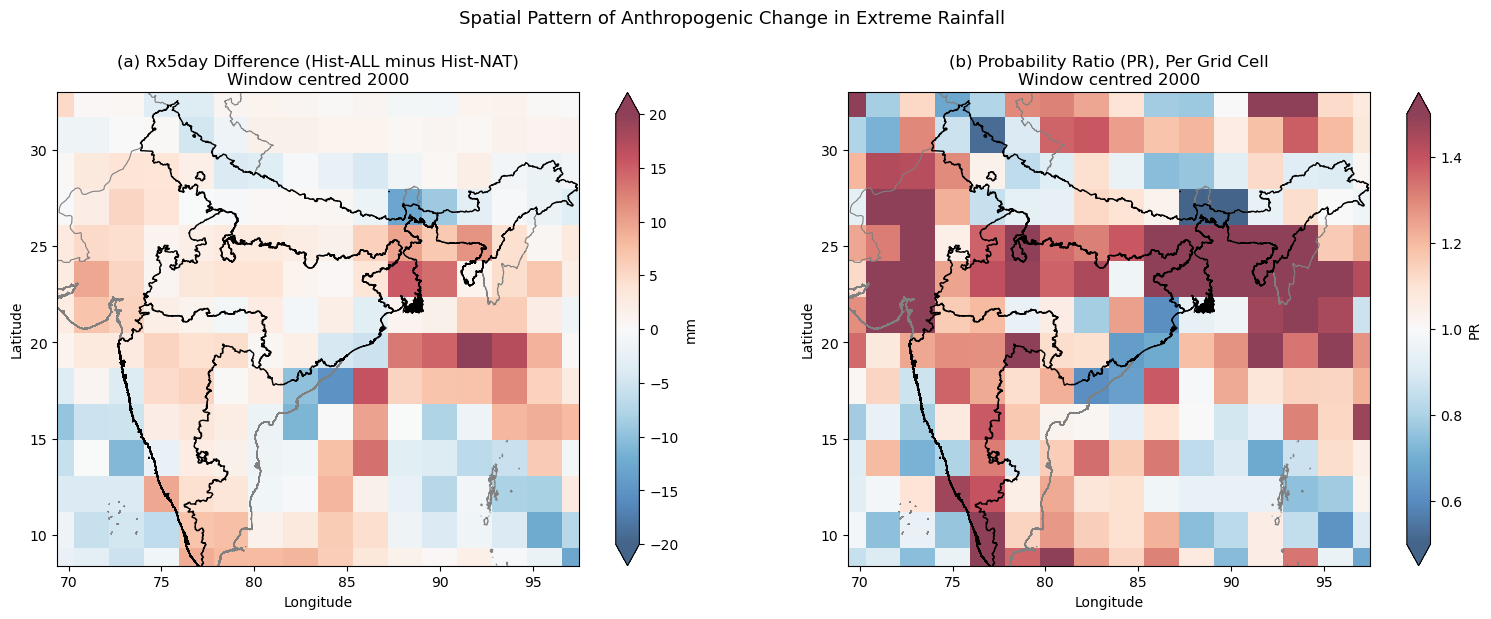

In [55]:
illustration_year = 2000

ant_window_grid = rx5day_ant_grid.sel(year=slice(illustration_year - HALF_BEFORE, illustration_year + HALF_AFTER))
nat_window_grid = rx5day_nat_grid.sel(year=slice(illustration_year - HALF_BEFORE, illustration_year + HALF_AFTER))

ant_mean_grid = ant_window_grid.mean(dim=['member', 'year'])
nat_mean_grid = nat_window_grid.mean(dim=['member', 'year'])
rx5day_diff = ant_mean_grid - nat_mean_grid

pr_map = PR_per_cell.sel(year=illustration_year)

import matplotlib.colors as mcolors

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

india_outline = gdf_clean.dissolve().boundary

# Tighter northern crop, just above IGP's true boundary (lat 32.58), not the full grid extent
LAT_VIEW_MAX = 33

norm_diff = mcolors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=20)
im1 = ax1.pcolormesh(rx5day_diff.lon, rx5day_diff.lat, rx5day_diff,
                      cmap='RdBu_r', norm=norm_diff, shading='nearest', alpha=0.75, zorder=1)
india_outline.plot(ax=ax1, color='grey', linewidth=0.8, zorder=2)
for region in REGION_ORDER:
    gdf_regions.loc[[region]].boundary.plot(ax=ax1, color='black', linewidth=1, zorder=3)
ax1.set_xlim(float(rx5day_diff.lon.min()), float(rx5day_diff.lon.max()))
ax1.set_ylim(float(rx5day_diff.lat.min()), LAT_VIEW_MAX)
ax1.set_title(f'(a) Rx5day Difference (Hist-ALL minus Hist-NAT)\nWindow centred {illustration_year}')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(im1, ax=ax1, label='mm', extend='both')

norm_pr = mcolors.TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)
im2 = ax2.pcolormesh(pr_map.lon, pr_map.lat, pr_map,
                      cmap='RdBu_r', norm=norm_pr, shading='nearest', alpha=0.75, zorder=1)
india_outline.plot(ax=ax2, color='grey', linewidth=0.8, zorder=2)
for region in REGION_ORDER:
    gdf_regions.loc[[region]].boundary.plot(ax=ax2, color='black', linewidth=1, zorder=3)
ax2.set_xlim(float(pr_map.lon.min()), float(pr_map.lon.max()))
ax2.set_ylim(float(pr_map.lat.min()), LAT_VIEW_MAX)
ax2.set_title(f'(b) Probability Ratio (PR), Per Grid Cell\nWindow centred {illustration_year}')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
plt.colorbar(im2, ax=ax2, label='PR', extend='both')

fig.suptitle('Spatial Pattern of Anthropogenic Change in Extreme Rainfall', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
# Reported in the dissertation as Figure 13
plt.savefig(OUTPUT_DIR + 'figure_rx5day_pr_difference_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
import scipy.stats as stats
diff_flat = rx5day_diff.values.flatten()
pr_flat = pr_map.values.flatten()
valid = ~np.isnan(diff_flat) & ~np.isnan(pr_flat)
r, p = stats.pearsonr(diff_flat[valid], pr_flat[valid])
print(f"Spatial correlation between Rx5day difference and PR: r={r:.3f}, p={p:.3f}")

Spatial correlation between Rx5day difference and PR: r=0.686, p=0.000


In [57]:
print("rx5day_ant_grid lat range:", float(rx5day_ant_grid.lat.min()), "to", float(rx5day_ant_grid.lat.max()))
print("rx5day_ant_grid lon range:", float(rx5day_ant_grid.lon.min()), "to", float(rx5day_ant_grid.lon.max()))

rx5day_ant_grid lat range: 8.393668907692383 to 34.50724334150103
rx5day_ant_grid lon range: 69.375 to 97.5


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Figure 17: Regional PR(t), PR-First Method</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Regenerated using the PR-first method with member-resampled bootstrap confidence intervals. Significance rates: Central India 38%, Indo Gangetic Plain 22%, Northeast 45%, Western Ghats 22%.</p>
</div>

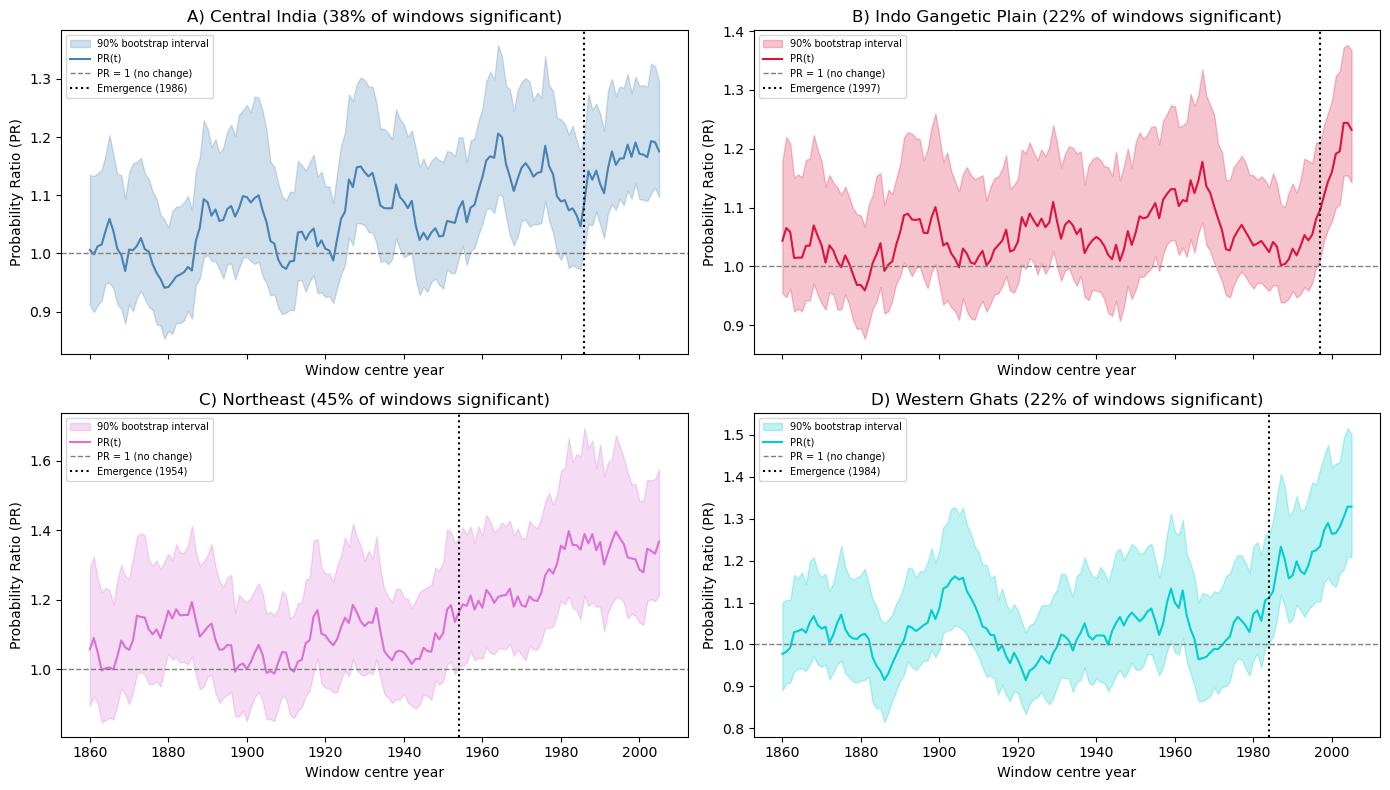

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()
panel_letters = ['A)', 'B)', 'C)', 'D)']
region_colors = {
    'Central_India': 'steelblue',
    'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid',
    'Western_Ghats': 'darkturquoise'
}

emergence_years = {
    'Central_India': 1986,
    'Indo_Gangetic_Plain': 1997,
    'Northeast': 1954,
    'Western_Ghats': 1984
}

for i, (region, letter) in enumerate(zip(REGION_ORDER, panel_letters)):
    ax = axes[i]
    sub = pr_df_prfirst[pr_df_prfirst.region == region].sort_values('year')
    pct_sig = sub['significant'].mean() * 100
    color = region_colors[region]

    ax.fill_between(sub.year, sub.PR_ci_5, sub.PR_ci_95, alpha=0.25,
                     color=color, label='90% bootstrap interval')
    ax.plot(sub.year, sub.PR, color=color, label='PR(t)')

    ax.axhline(1, color='grey', linestyle='--', linewidth=1, label='PR = 1 (no change)')
    ax.axvline(emergence_years[region], color='black', linestyle=':', linewidth=1.5,
               label=f'Emergence ({emergence_years[region]})')

    ax.set_title(f'{letter} {region.replace("_", " ")} ({pct_sig:.0f}% of windows significant)')
    ax.set_xlabel('Window centre year')
    ax.set_ylabel('Probability Ratio (PR)')
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
# Reported in the dissertation as Figure 17
plt.savefig(OUTPUT_DIR + 'figure17_pr_headline.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
pr_df_prfirst.to_csv(OUTPUT_DIR + 'pr_far_rolling_window_results_PRFIRST.csv', index=False)
print('Saved pr_far_rolling_window_results_PRFIRST.csv')
print(f'Rows: {len(pr_df_prfirst)}, columns: {list(pr_df_prfirst.columns)}')

Saved pr_far_rolling_window_results_PRFIRST.csv
Rows: 584, columns: ['region', 'year', 'PR', 'FAR', 'PR_ci_5', 'PR_ci_95', 'significant']


In [60]:
def find_permanent_emergence(sub):
    sub = sub.sort_values('year').reset_index(drop=True)
    sig = sub['significant'].values
    years = sub['year'].values

    non_sig_idx = np.where(~sig)[0]
    if len(non_sig_idx) == 0:
        return years[0], 'significant from earliest window onward'
    last_non_sig = non_sig_idx[-1]
    if last_non_sig == len(sig) - 1:
        return None, 'not yet permanently significant by end of record'
    return years[last_non_sig + 1], 'permanent emergence confirmed'

print(f"{'Region':<22} {'Emergence year':<16} Note")
for region in REGION_ORDER:
    sub = pr_df_prfirst[pr_df_prfirst.region == region]
    year, note = find_permanent_emergence(sub)
    print(f"{region:<22} {str(year):<16} {note}")

Region                 Emergence year   Note
Central_India          1986             permanent emergence confirmed
Indo_Gangetic_Plain    1997             permanent emergence confirmed
Northeast              1954             permanent emergence confirmed
Western_Ghats          1984             permanent emergence confirmed


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Figure 7: Window Illustration, PR-First Method</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Illustrates the PR-first method for one representative grid cell per region (window centred 2000): each grid cell has its own R0 threshold and its own pooled 600 samples (30 members x 20 years). PR is computed independently at this cell, then the same calculation is repeated at every grid cell in the region and area-averaged.</p>
</div>

In [61]:
target_prs = {}
for region in REGION_ORDER:
    val = pr_df_prfirst[(pr_df_prfirst.region == region) & (pr_df_prfirst.year == 2000)]['PR'].values[0]
    target_prs[region] = val
    print(f"{region}: target PR (year 2000) = {val:.3f}")

rep_cells_typical = {}
for region in REGION_ORDER:
    mask = frac_overlap_mpi.sel(region=region) > 0.1
    lat_idx, lon_idx = np.where(mask.values)

    closest_diff = np.inf
    best_cell = None
    for la, lo in zip(lat_idx, lon_idx):
        ant_vals = rx5day_ant_grid.isel(lat=la, lon=lo).sel(year=slice(2000-HALF_BEFORE, 2000+HALF_AFTER)).values.flatten()
        nat_vals = rx5day_nat_grid.isel(lat=la, lon=lo).sel(year=slice(2000-HALF_BEFORE, 2000+HALF_AFTER)).values.flatten()
        r0_cell = R0_grid.values[la, lo]
        p_ant = np.mean(ant_vals > r0_cell)
        p_nat = np.mean(nat_vals > r0_cell)
        if p_nat > 0:
            pr_cell = p_ant / p_nat
            diff = abs(pr_cell - target_prs[region])
            if diff < closest_diff:
                closest_diff = diff
                best_cell = (float(R0_grid.lat[la]), float(R0_grid.lon[lo]), pr_cell)

    rep_cells_typical[region] = (best_cell[0], best_cell[1])
    print(f"{region}: lat={best_cell[0]:.2f}, lon={best_cell[1]:.2f}, PR={best_cell[2]:.3f} (target={target_prs[region]:.3f})")

Central_India: target PR (year 2000) = 1.171
Indo_Gangetic_Plain: target PR (year 2000) = 1.160
Northeast: target PR (year 2000) = 1.286
Western_Ghats: target PR (year 2000) = 1.264
Central_India: lat=21.45, lon=75.00, PR=1.159 (target=1.171)
Indo_Gangetic_Plain: lat=27.05, lon=82.50, PR=1.125 (target=1.160)
Northeast: lat=27.05, lon=93.75, PR=1.117 (target=1.286)
Western_Ghats: lat=19.59, lon=76.88, PR=1.283 (target=1.264)


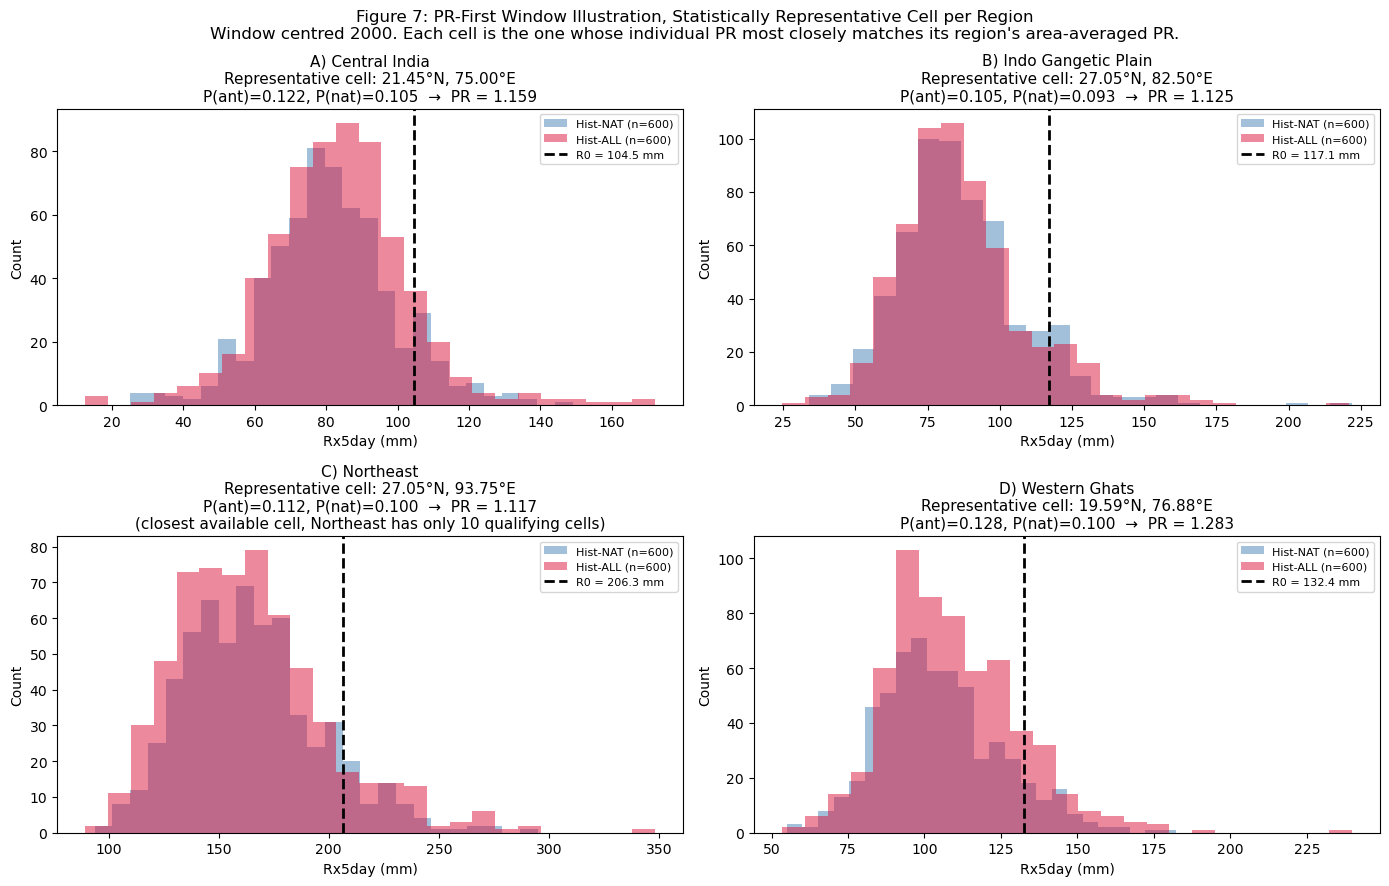

Figure 7 (typical-cell version) saved


In [62]:
# rep_cells_typical selected as the cell whose individual PR is closest to
# the region's area-averaged PR for this window (2000), statistically
# representative, not just geographically central (see selection cell above)

illustration_year = 2000
panel_letters = ['A)', 'B)', 'C)', 'D)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    lat_val, lon_val = rep_cells_typical[region]

    R0_illust = float(R0_grid.sel(lat=lat_val, lon=lon_val, method='nearest'))

    ant_cell = rx5day_ant_grid.sel(lat=lat_val, lon=lon_val, method='nearest')
    nat_cell = rx5day_nat_grid.sel(lat=lat_val, lon=lon_val, method='nearest')

    ant_window = ant_cell.sel(year=slice(illustration_year - HALF_BEFORE, illustration_year + HALF_AFTER)).values.flatten()
    nat_window = nat_cell.sel(year=slice(illustration_year - HALF_BEFORE, illustration_year + HALF_AFTER)).values.flatten()

    P_ant_illust = np.mean(ant_window > R0_illust)
    P_nat_illust = np.mean(nat_window > R0_illust)
    PR_illust = P_ant_illust / P_nat_illust

    ax.hist(nat_window, bins=25, alpha=0.5, label=f'Hist-NAT (n={len(nat_window)})', color='steelblue')
    ax.hist(ant_window, bins=25, alpha=0.5, label=f'Hist-ALL (n={len(ant_window)})', color='crimson')
    ax.axvline(R0_illust, color='black', linestyle='--', linewidth=2, label=f'R0 = {R0_illust:.1f} mm')

    ax.set_xlabel('Rx5day (mm)')
    ax.set_ylabel('Count')
    title = (f'{panel_letters[i]} {region.replace("_", " ")}\n'
             f'Representative cell: {lat_val:.2f}°N, {lon_val:.2f}°E\n'
             f'P(ant)={P_ant_illust:.3f}, P(nat)={P_nat_illust:.3f}  →  PR = {PR_illust:.3f}')
    if region == 'Northeast':
        title += '\n(closest available cell, Northeast has only 10 qualifying cells)'
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle(f'Figure 7: PR-First Window Illustration, Statistically Representative Cell per Region\n'
             f'Window centred {illustration_year}. Each cell is the one whose individual PR most closely matches its region\'s area-averaged PR.', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure7_window_illustration_typical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 (typical-cell version) saved')

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Figure 8: Time-Evolving Rx5day for the Representative Grid Cell</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Uses the same representative grid cell per region as Figure 7 to isolate the temporal change within the window, shown here as a 20-year rolling mean across the full record.</p>
</div>

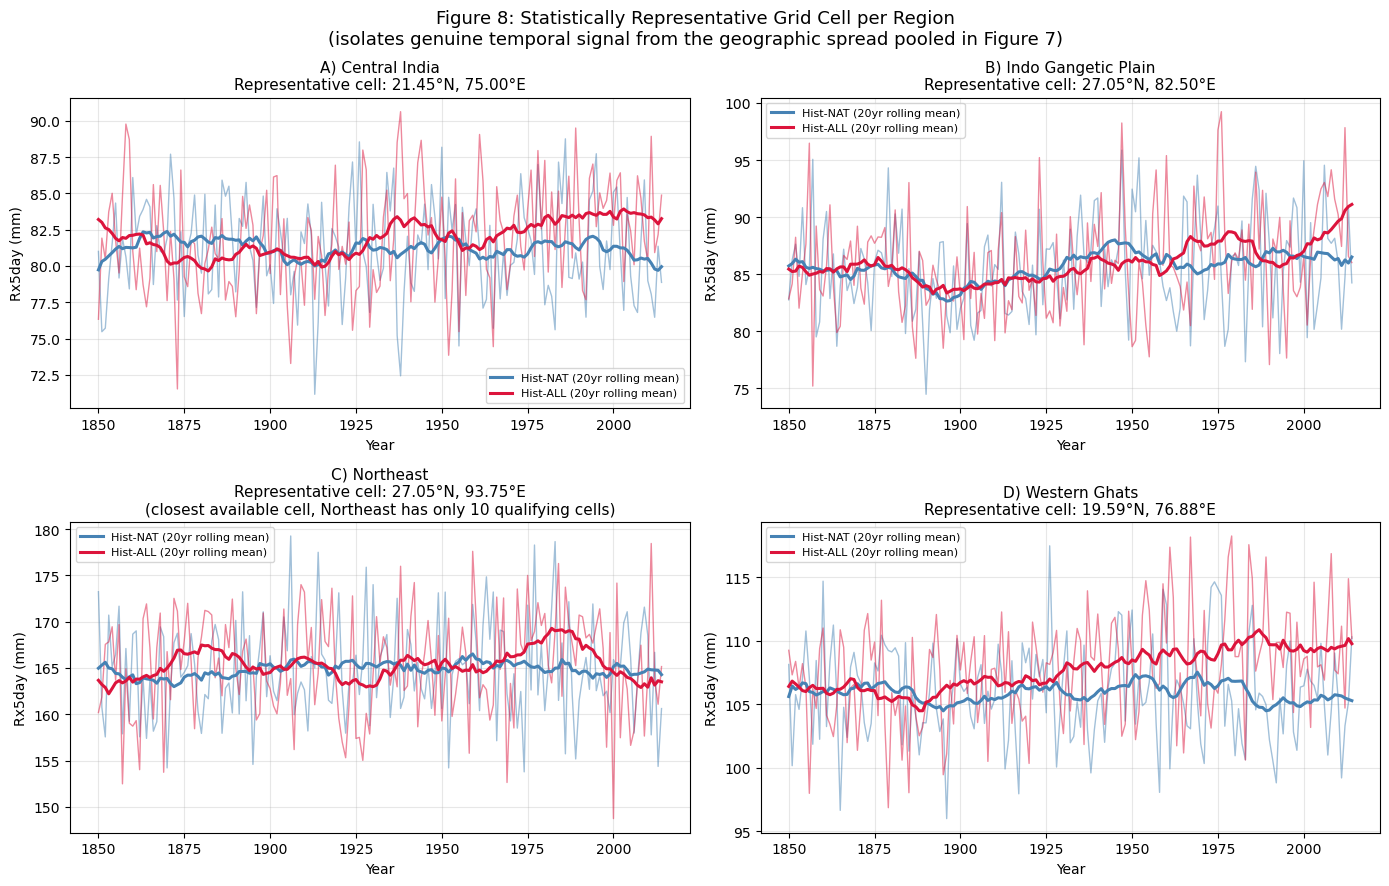

In [63]:
panel_letters = ['A)', 'B)', 'C)', 'D)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    lat_val, lon_val = rep_cells_typical[region]

    ant_cell = rx5day_ant_grid.sel(lat=lat_val, lon=lon_val, method='nearest')
    nat_cell = rx5day_nat_grid.sel(lat=lat_val, lon=lon_val, method='nearest')

    ant_mean = ant_cell.mean(dim='member')
    nat_mean = nat_cell.mean(dim='member')

    ax.plot(nat_mean.year, nat_mean, color='steelblue', linewidth=1, alpha=0.5)
    ax.plot(ant_mean.year, ant_mean, color='crimson', linewidth=1, alpha=0.5)

    nat_smooth = nat_mean.rolling(year=20, center=True, min_periods=10).mean()
    ant_smooth = ant_mean.rolling(year=20, center=True, min_periods=10).mean()

    ax.plot(nat_smooth.year, nat_smooth, color='steelblue', linewidth=2.2, label='Hist-NAT (20yr rolling mean)')
    ax.plot(ant_smooth.year, ant_smooth, color='crimson', linewidth=2.2, label='Hist-ALL (20yr rolling mean)')

    ax.set_xlabel('Year')
    ax.set_ylabel('Rx5day (mm)')
    title = f'{panel_letters[i]} {region.replace("_", " ")}\nRepresentative cell: {lat_val:.2f}°N, {lon_val:.2f}°E'
    if region == 'Northeast':
        title += '\n(closest available cell, Northeast has only 10 qualifying cells)'
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Figure 8: Statistically Representative Grid Cell per Region\n'
             '(isolates genuine temporal signal from the geographic spread pooled in Figure 7)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure8_time_variation_supplement_typical.png', dpi=150, bbox_inches='tight')
plt.show()